# Projekat: Segmentacija E-Commerce Kupaca i Narudzbina 

**Tema**: Nenadgledano ucenje - Klasterizacija

**Dataset**: [E-Commerce Sales Dataset (Amazon Sale Report)](https://www.kaggle.com/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data)


## Definicija problema i ucitavanje podataka

### Cilj Projekta

**Kontekst:**  
Dataset sadrzi preko 111,000 narudzbina sa Amazon India platforme tokom perioda Mart-Jun 2022. Cilj je otkriti prirodne segmente kupaca u podacima koristeci tehnike nenadgledanog ucenja.

**Problem:**  
Podaci nemaju labele, ne znamo unapred koliko razlicitih grupa kupaca postoji niti kakve su njihove karakteristike. Potrebno je istraziti skrivene strukture u podacima i identifikovati smislene segmente.

**Tehnicki cilj:**  
Primenom vise algoritama klasterizacije identifikovati grupe narudzbina sa slicnim karakteristikama, na osnovu:
- **Iznosa narudzbine** (Amount) - cena proizvoda
- **Ukupnog prihoda** (Revenue = Amount × Qty) - ukupna vrednost narudzbine
- **Kategorije proizvoda** (Category) - tip proizvoda (Set, kurta, Western Dress...)
- **Tipa kupca** (B2B/B2C) - poslovni ili privatni kupac
- **Sezone** (Month) - mesec narudzbine

**Ocekivani ishod:**  
- Identifikacija optimalnog broja klastera
- Poredjenje performansi razlicitih algoritama
- Jasna biznis interpretacija svakog klastera (npr. Budget Kupci, Premium Kupci, Bulk Kupci)
- Vizualizacija klastera pomocu tehnika redukcije dimenzionalnosti (PCA, t-SNE)

### Ucitavanje biblioteka i skupa podataka.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import NearestCentroid
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

In [7]:
df = pd.read_csv('data/amazon_sale_report.csv')

df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


## Deskriptivna analiza i priprema podataka

### Istrazivanje dataseta

In [8]:
print(f"Shape: {df.shape}")

print("\nKolone(Datatypes):")

for i,col_name in enumerate(df.columns, 1):
    print(f"{i}:{col_name}({df[col_name].dtypes})")

print(f"\nTipovi podataka:\n{df.dtypes}")

print(f"\nMissing vrednosti:\n{df.isnull().sum()}")

print(f"\nStatistike:\n{df.describe()}")

Shape: (128975, 24)

Kolone(Datatypes):
1:index(int64)
2:Order ID(str)
3:Date(str)
4:Status(str)
5:Fulfilment(str)
6:Sales Channel (str)
7:ship-service-level(str)
8:Style(str)
9:SKU(str)
10:Category(str)
11:Size(str)
12:ASIN(str)
13:Courier Status(str)
14:Qty(int64)
15:currency(str)
16:Amount(float64)
17:ship-city(str)
18:ship-state(str)
19:ship-postal-code(float64)
20:ship-country(str)
21:promotion-ids(str)
22:B2B(bool)
23:fulfilled-by(str)
24:Unnamed: 22(object)

Tipovi podataka:
index                   int64
Order ID                  str
Date                      str
Status                    str
Fulfilment                str
Sales Channel             str
ship-service-level        str
Style                     str
SKU                       str
Category                  str
Size                      str
ASIN                      str
Courier Status            str
Qty                     int64
currency                  str
Amount                float64
ship-city                 str
shi

In [9]:
missing_percent = df.isnull().sum() / len(df) *100

print("Null vrednosti u % po koloni: \n", missing_percent[missing_percent>0])
print("Total NaN count: ", df.isnull().sum().sum())

Null vrednosti u % po koloni: 
 Courier Status       5.328164
currency             6.043807
Amount               6.043807
ship-city            0.025586
ship-state           0.025586
ship-postal-code     0.025586
ship-country         0.025586
promotion-ids       38.110487
fulfilled-by        69.546811
Unnamed: 22         38.030626
dtype: float64
Total NaN count:  210495


### Data cleanup

In [10]:
df = df.copy()

#### Brisanje beskorisnih kolona

In [11]:
df = df.drop(columns=[
    'Unnamed: 22',
    'fulfilled-by',
    'Order ID',
    'promotion-ids',
    'ASIN',
    'SKU',
    'index',
    'ship-country',
    'ship-postal-code',
    'currency'
])

df.shape

(128975, 14)

#### Otklanjanja duplikata i NaN

In [12]:
print(f'Duplikati: ', df.duplicated().sum())

df = df.drop_duplicates()

print(f'Duplikati: ', df.duplicated().sum())

df.shape

Duplikati:  2442
Duplikati:  0


(126533, 14)

In [13]:
# Otklananje 0 i NaN podataka
df = df[df['Amount'] > 0]
df = df[df['Qty'] > 0]
df = df.dropna(subset=['Amount', 'Qty'])

# Popunjavanje NaN vrednosti
df['Courier Status'] = df['Courier Status'].fillna('Cancelled')
df['ship-city'] = df['ship-city'].fillna('Unknown-city')
df['ship-state'] = df['ship-state'].fillna('Unknown-state')

print(f'Shape nakon ciscenja: {df.shape}')
print(f'\nPreostale NaN vrednosti:\n{df.isnull().sum()}')

Shape nakon ciscenja: (111878, 14)

Preostale NaN vrednosti:
Date                  0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Style                 0
Category              0
Size                  0
Courier Status        0
Qty                   0
Amount                0
ship-city             0
ship-state            0
B2B                   0
dtype: int64


### Exploratory Data Analysis (EDA)

#### Amount

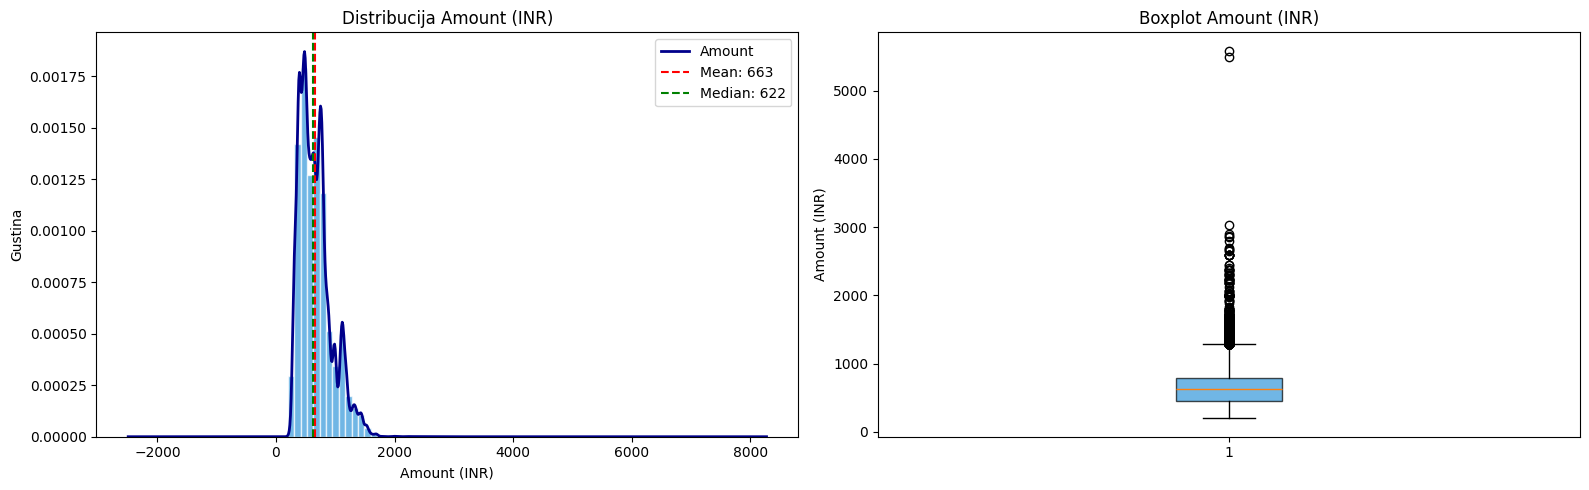

Deskriptivne statistike za Amount:
  Mean:     663.16 INR
  Median:   622.00 INR
  Std:      269.98 INR
  Min:      199.00 INR
  Max:      5584.00 INR
  Skewness: 1.161 (desno zakrivljena)
  Kurtosis: 3.246 (teski repovi)
  IQR:      329.00 INR


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df['Amount'].dropna(), bins=50, color='#3498db', edgecolor='white', density=True, alpha=0.7)
df['Amount'].dropna().plot.kde(ax=axes[0], color='darkblue', linewidth=2)
axes[0].axvline(df['Amount'].mean(), color='red', linestyle='--',
            label=f'Mean: {df["Amount"].mean():.0f}')
axes[0].axvline(df['Amount'].median(), color='green', linestyle='--',
            label=f'Median: {df["Amount"].median():.0f}')
axes[0].set_title('Distribucija Amount (INR)')
axes[0].set_xlabel('Amount (INR)')
axes[0].set_ylabel('Gustina')
axes[0].legend()

bp = axes[1].boxplot(df['Amount'].dropna(), vert=True, patch_artist=True,
                     boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[1].set_title('Boxplot Amount (INR)')
axes[1].set_ylabel('Amount (INR)')

plt.tight_layout()
plt.show()

skewness = df['Amount'].skew()
kurtosis = df['Amount'].kurtosis()
print(f"Deskriptivne statistike za Amount:")
print(f"  Mean:     {df['Amount'].mean():.2f} INR")
print(f"  Median:   {df['Amount'].median():.2f} INR")
print(f"  Std:      {df['Amount'].std():.2f} INR")
print(f"  Min:      {df['Amount'].min():.2f} INR")
print(f"  Max:      {df['Amount'].max():.2f} INR")
print(f"  Skewness: {skewness:.3f} {'(desno zakrivljena)' if skewness > 0 else '(levo zakrivljena)'}")
print(f"  Kurtosis: {kurtosis:.3f} {'(teski repovi)' if kurtosis > 0 else '(laki repovi)'}")
print(f"  IQR:      {df['Amount'].quantile(0.75) - df['Amount'].quantile(0.25):.2f} INR")

#### Feature engineering - Amount log

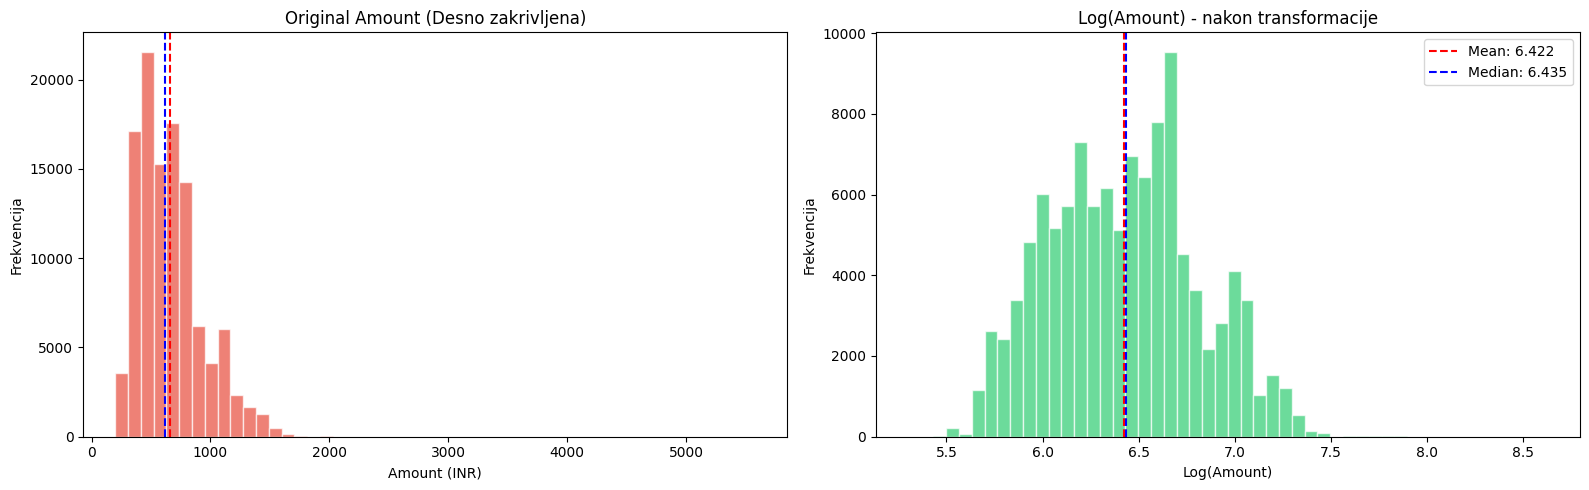

Skewness pre log transformacije:  1.161
Skewness posle log transformacije: 0.158
Poboljsanje: 1.002


In [15]:
df['Amount_log'] = np.log1p(df['Amount'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df['Amount'], bins=50, color='#e74c3c', edgecolor='white', alpha=0.7)
axes[0].set_title('Original Amount (Desno zakrivljena)')
axes[0].axvline(df['Amount'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["Amount"].mean():.3f}')
axes[0].axvline(df['Amount'].median(), color='blue', linestyle='--',
                label=f'Median: {df["Amount"].median():.3f}')
axes[0].set_xlabel('Amount (INR)')
axes[0].set_ylabel('Frekvencija')

axes[1].hist(df['Amount_log'], bins=50, color='#2ecc71', edgecolor='white', alpha=0.7)
axes[1].axvline(df['Amount_log'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["Amount_log"].mean():.3f}')
axes[1].axvline(df['Amount_log'].median(), color='blue', linestyle='--',
                label=f'Median: {df["Amount_log"].median():.3f}')
axes[1].set_title('Log(Amount) - nakon transformacije')
axes[1].set_xlabel('Log(Amount)')
axes[1].set_ylabel('Frekvencija')
axes[1].legend()

plt.tight_layout()
plt.show()

skew_before = df['Amount'].skew()
skew_after = df['Amount_log'].skew()
print(f"Skewness pre log transformacije:  {skew_before:.3f}")
print(f"Skewness posle log transformacije: {skew_after:.3f}")
print(f"Poboljsanje: {abs(skew_before) - abs(skew_after):.3f}")

#### Qty

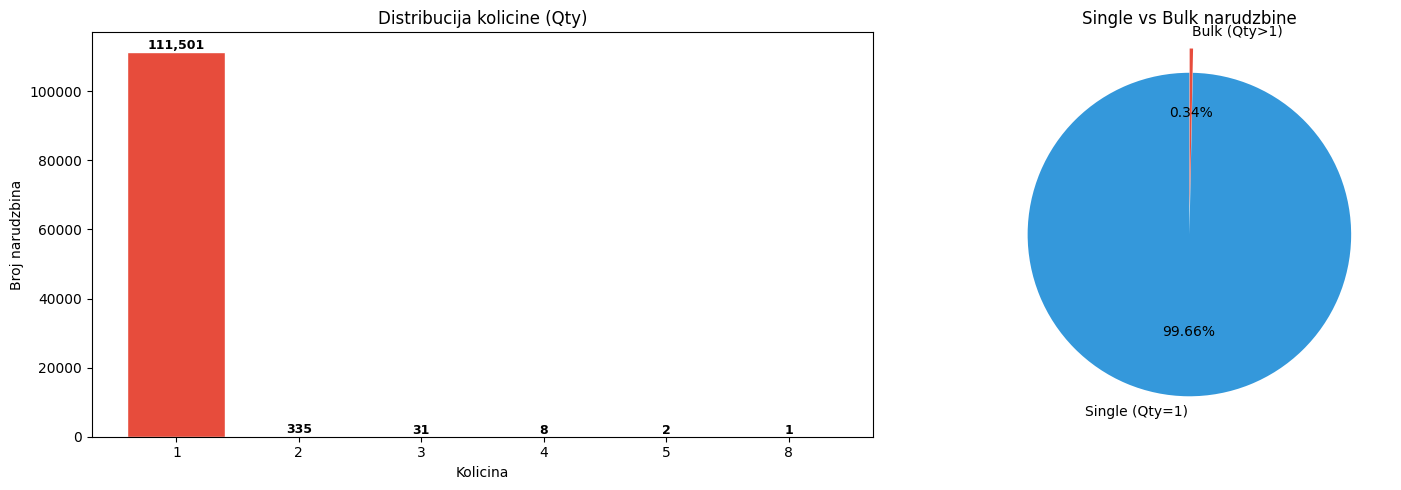

Qty statistike:
  Ukupno narudzbina: 111,878
  Single (Qty=1):    111,501 (99.66%)
  Bulk (Qty>1):      377 (0.34%)
  Max Qty:           8
  Mean Qty:          1.004


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

qty_counts = df['Qty'].value_counts().sort_index()
bars = axes[0].bar(qty_counts.index.astype(str), qty_counts.values, color='#e74c3c', edgecolor='white')
axes[0].set_title('Distribucija kolicine (Qty)')
axes[0].set_xlabel('Kolicina')
axes[0].set_ylabel('Broj narudzbina')

for bar, val in zip(bars, qty_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

single = (df['Qty'] == 1).sum()
bulk = (df['Qty'] > 1).sum()
axes[1].pie([single, bulk], labels=['Single (Qty=1)', f'Bulk (Qty>1)'],
            autopct='%1.2f%%', colors=['#3498db', '#e74c3c'],
            startangle=90, explode=[0, 0.15])
axes[1].set_title('Single vs Bulk narudzbine')

plt.tight_layout()
plt.show()

print(f"Qty statistike:")
print(f"  Ukupno narudzbina: {len(df):,}")
print(f"  Single (Qty=1):    {single:,} ({single/len(df)*100:.2f}%)")
print(f"  Bulk (Qty>1):      {bulk:,} ({bulk/len(df)*100:.2f}%)")
print(f"  Max Qty:           {df['Qty'].max()}")
print(f"  Mean Qty:          {df['Qty'].mean():.3f}")

#### Revenue

      Amount  Qty  Revenue
265   2130.0    2   4260.0
647   2224.0    2   4448.0
1018  1518.0    2   3036.0
1696  1308.0    2   2616.0
2107  1128.0    3   3384.0
2185   972.0    2   1944.0
2189   864.0    2   1728.0
2583   990.0    2   1980.0
3289  2175.0    3   6525.0
5320   720.0    2   1440.0


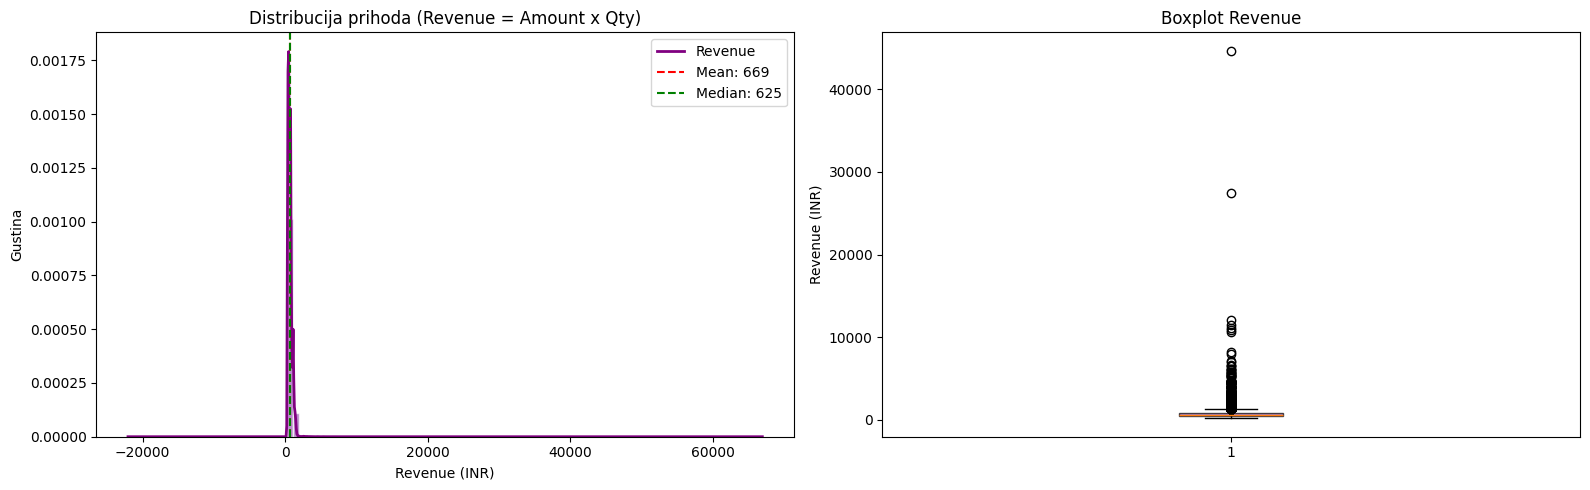

Revenue statistike:
  Mean:     668.79 INR
  Median:   625.00 INR
  Std:      343.01 INR
  Skewness: 26.557
  Kurtosis: 2815.797

  Korelacija Amount i Revenue: 0.8653


In [17]:
df['Revenue'] = df['Amount'] * df['Qty']

print(df[df['Qty'] > 1][['Amount', 'Qty', 'Revenue']].head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df['Revenue'], bins=50, color="#9b59b6", edgecolor="white", density=True, alpha=0.7)
df['Revenue'].plot.kde(ax=axes[0], color='purple', linewidth=2)
axes[0].axvline(df['Revenue'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["Revenue"].mean():.0f}')
axes[0].axvline(df['Revenue'].median(), color='green', linestyle='--',
                label=f'Median: {df["Revenue"].median():.0f}')
axes[0].set_title('Distribucija prihoda (Revenue = Amount x Qty)')
axes[0].set_xlabel('Revenue (INR)')
axes[0].set_ylabel('Gustina')
axes[0].legend()

axes[1].boxplot(df['Revenue'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#9b59b6', alpha=0.7))
axes[1].set_title('Boxplot Revenue')
axes[1].set_ylabel('Revenue (INR)')

plt.tight_layout()
plt.show()

print(f"Revenue statistike:")
print(f"  Mean:     {df['Revenue'].mean():.2f} INR")
print(f"  Median:   {df['Revenue'].median():.2f} INR")
print(f"  Std:      {df['Revenue'].std():.2f} INR")
print(f"  Skewness: {df['Revenue'].skew():.3f}")
print(f"  Kurtosis: {df['Revenue'].kurtosis():.3f}")

# Korelacija Amount vs Revenue
corr_ar = df['Amount'].corr(df['Revenue'])
print(f"\n  Korelacija Amount i Revenue: {corr_ar:.4f}")

99.7% narudzbina ima Qty=1, sto znaci da je `Revenue` prakticno identican `Amount`-u za ogromnu vecinu podataka. Ovo je vazno za feature selection u klasterizaciji. Ova dva feature-a su skoro potpuno redundantna.


#### Category

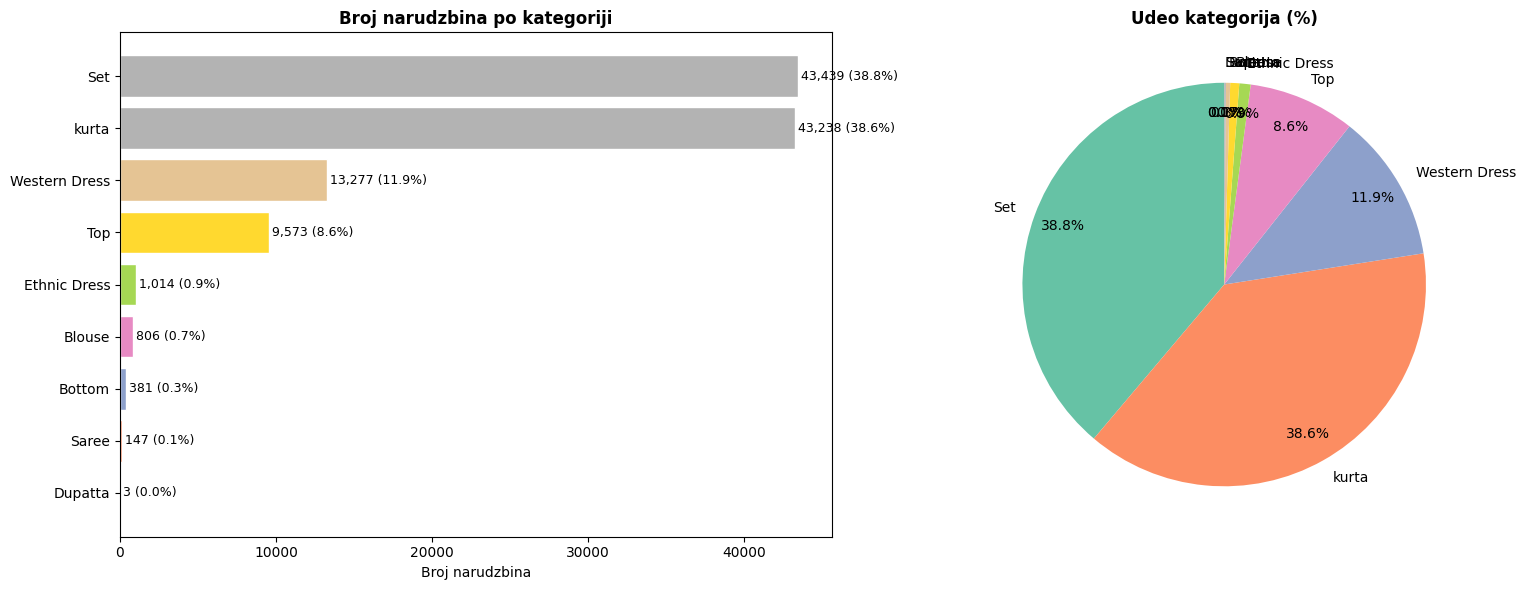

Distribucija po kategorijama:
  Set            : 43,439 ( 38.8%)
  kurta          : 43,238 ( 38.6%)
  Western Dress  : 13,277 ( 11.9%)
  Top            :  9,573 (  8.6%)
  Ethnic Dress   :  1,014 (  0.9%)
  Blouse         :    806 (  0.7%)
  Bottom         :    381 (  0.3%)
  Saree          :    147 (  0.1%)
  Dupatta        :      3 (  0.0%)

  Dominantne 3 kategorije cine 89.3% dataseta


In [18]:
cat_counts = df['Category'].value_counts()
cat_pct = cat_counts / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.Set2(np.linspace(0, 1, len(cat_counts)))
bars = axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1],
                     color=colors, edgecolor='white')
axes[0].set_title('Broj narudzbina po kategoriji', fontweight='bold')
axes[0].set_xlabel('Broj narudzbina')

for bar, val, pct in zip(bars, cat_counts.values[::-1], cat_pct.values[::-1]):
    axes[0].text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
                 f'{val:,} ({pct:.1f}%)', va='center', fontsize=9)

axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, pctdistance=0.85)
axes[1].set_title('Udeo kategorija (%)', fontweight='bold')

plt.tight_layout()
plt.show()

print("Distribucija po kategorijama:")
for cat, cnt in cat_counts.items():
    print(f"  {cat:15s}: {cnt:>6,} ({cnt/len(df)*100:5.1f}%)")
print(f"\n  Dominantne 3 kategorije cine {cat_pct.head(3).sum():.1f}% dataseta")

#### Tip kupca (B2B/B2C)

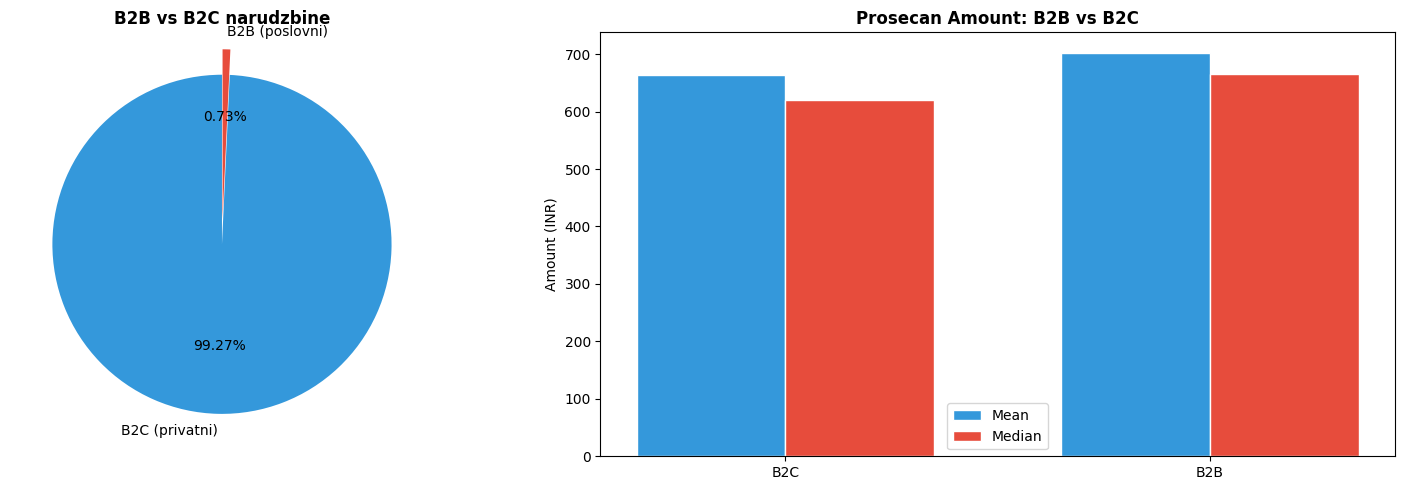

Tip kupca:
  B2C (privatni): 111,056 (99.27%)
  B2B (poslovni): 822 (0.73%)

  B2B prosecan Amount: 703 INR
  B2C prosecan Amount: 663 INR

  Napomena: Samo 0.73% narudzbina je B2B - minimalan uticaj na klasterizaciju


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

b2b_count = df['B2B'].value_counts()
labels = ['B2C (privatni)', 'B2B (poslovni)']
colors = ['#3498db', '#e74c3c']

axes[0].pie(b2b_count.values, labels=labels, autopct='%1.2f%%',
            colors=colors, startangle=90, explode=[0, 0.15])
axes[0].set_title('B2B vs B2C narudzbine', fontweight='bold')

b2b_stats = df.groupby('B2B')['Amount'].agg(['mean', 'median', 'count'])
b2b_stats.index = ['B2C', 'B2B']

x = np.arange(len(b2b_stats))
width = 0.35
axes[1].bar(x - width/2, b2b_stats['mean'], width, label='Mean', color='#3498db', edgecolor='white')
axes[1].bar(x + width/2, b2b_stats['median'], width, label='Median', color='#e74c3c', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(b2b_stats.index)
axes[1].set_ylabel('Amount (INR)')
axes[1].set_title('Prosecan Amount: B2B vs B2C', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

b2c_count = (df['B2B'] == False).sum()
b2b_real = (df['B2B'] == True).sum()
print(f"Tip kupca:")
print(f"  B2C (privatni): {b2c_count:,} ({b2c_count/len(df)*100:.2f}%)")
print(f"  B2B (poslovni): {b2b_real:,} ({b2b_real/len(df)*100:.2f}%)")
print(f"\n  B2B prosecan Amount: {df[df['B2B']==True]['Amount'].mean():.0f} INR")
print(f"  B2C prosecan Amount: {df[df['B2B']==False]['Amount'].mean():.0f} INR")
print(f"\n  Napomena: Samo {b2b_real/len(df)*100:.2f}% narudzbina je B2B - minimalan uticaj na klasterizaciju")

#### Mesecni trendovi

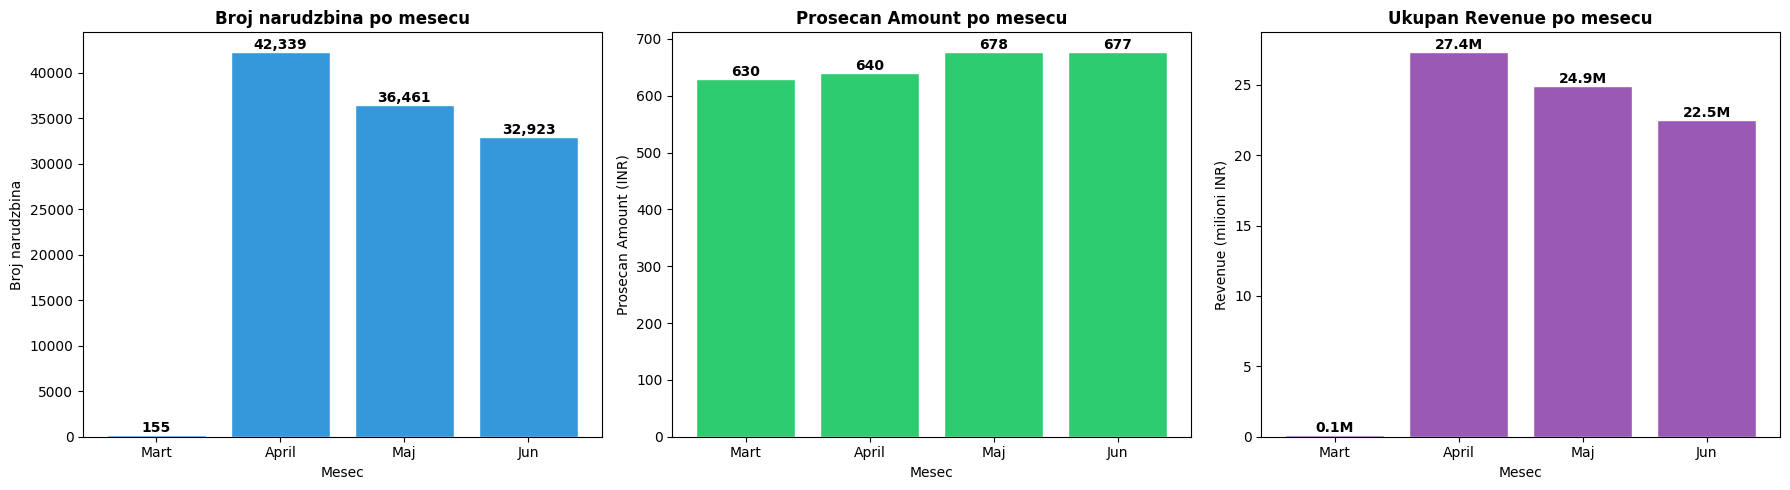

Mesecna statistika:
  Mart  :    155 narudzbina, avg=630 INR, total=0.1M INR
  April : 42,339 narudzbina, avg=640 INR, total=27.4M INR
  Maj   : 36,461 narudzbina, avg=678 INR, total=24.9M INR
  Jun   : 32,923 narudzbina, avg=677 INR, total=22.5M INR


In [20]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

month_labels = {3: 'Mart', 4: 'April', 5: 'Maj', 6: 'Jun'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Volumen narudzbina po mesecu
monthly_count = df.groupby('Month').size()
bars1 = axes[0].bar(monthly_count.index, monthly_count.values, color='#3498db', edgecolor='white')
axes[0].set_title('Broj narudzbina po mesecu', fontweight='bold')
axes[0].set_xlabel('Mesec')
axes[0].set_ylabel('Broj narudzbina')
axes[0].set_xticks(monthly_count.index)
axes[0].set_xticklabels([month_labels.get(m, m) for m in monthly_count.index])
for bar, val in zip(bars1, monthly_count.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Prosecan Amount po mesecu
monthly_avg = df.groupby('Month')['Amount'].mean()
bars2 = axes[1].bar(monthly_avg.index, monthly_avg.values, color='#2ecc71', edgecolor='white')
axes[1].set_title('Prosecan Amount po mesecu', fontweight='bold')
axes[1].set_xlabel('Mesec')
axes[1].set_ylabel('Prosecan Amount (INR)')
axes[1].set_xticks(monthly_avg.index)
axes[1].set_xticklabels([month_labels.get(m, m) for m in monthly_avg.index])
for bar, val in zip(bars2, monthly_avg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Ukupan Revenue po mesecu
monthly_revenue = df.groupby('Month')['Revenue'].sum()
bars3 = axes[2].bar(monthly_revenue.index, monthly_revenue.values / 1e6, color='#9b59b6', edgecolor='white')
axes[2].set_title('Ukupan Revenue po mesecu', fontweight='bold')
axes[2].set_xlabel('Mesec')
axes[2].set_ylabel('Revenue (milioni INR)')
axes[2].set_xticks(monthly_revenue.index)
axes[2].set_xticklabels([month_labels.get(m, m) for m in monthly_revenue.index])
for bar, val in zip(bars3, monthly_revenue.values / 1e6):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("Mesecna statistika:")
for m in sorted(df['Month'].unique()):
    subset = df[df['Month'] == m]
    print(f"  {month_labels.get(m, m):6s}: {len(subset):>6,} narudzbina, "
          f"avg={subset['Amount'].mean():.0f} INR, "
          f"total={subset['Revenue'].sum()/1e6:.1f}M INR")

#### Status narudzbine

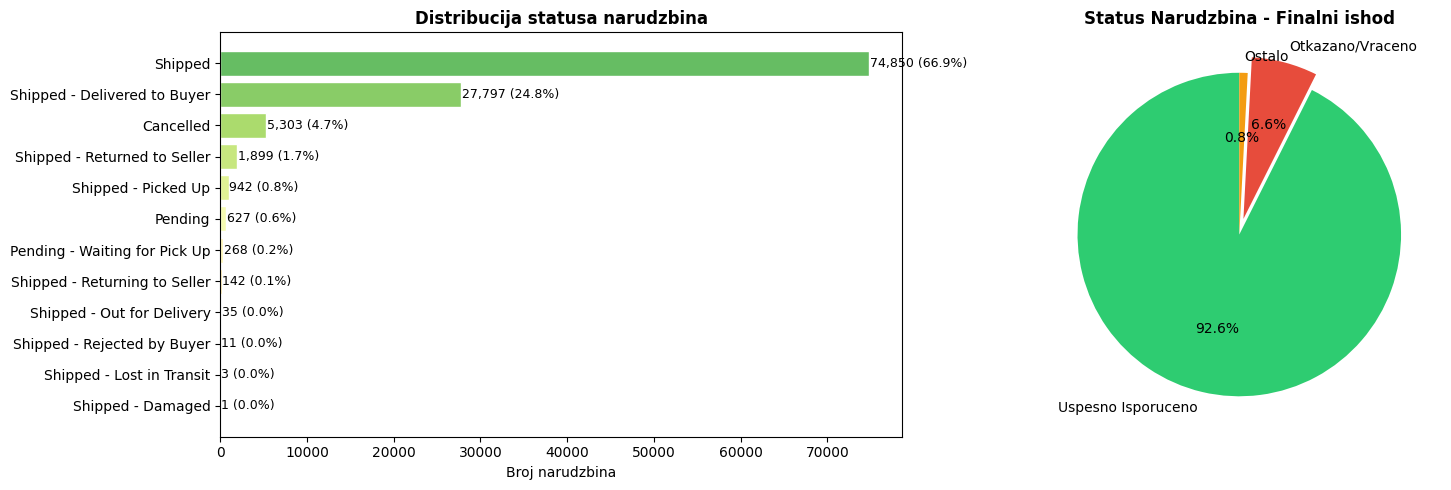


Status statistike:
  Uspesno isporuceno: 103,589 (92.6%)
  Otkazano/Vraceno:   7,359 (6.6%)
  Ostalo:           930 (0.8%)


In [21]:
status_counts = df['Status'].value_counts()
status_pct = status_counts / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors_status = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(status_counts)))
bars = axes[0].barh(status_counts.index[::-1], status_counts.values[::-1],
                     color=colors_status, edgecolor='white')
axes[0].set_title('Distribucija statusa narudzbina', fontweight='bold')
axes[0].set_xlabel('Broj narudzbina')
for bar, val, pct in zip(bars, status_counts.values[::-1], status_pct.values[::-1]):
    axes[0].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                 f'{val:,} ({pct:.1f}%)', va='center', fontsize=9)

# Uspesne isporuke
successful = df['Status'].isin([
    'Shipped', 
    'Shipped - Delivered to Buyer',
    'Shipped - Picked Up'
]).sum()

# Otkazane/vracene/neuspesne
failed = df['Status'].isin([
    'Cancelled',
    'Shipped - Returned to Seller',
    'Shipped - Returning to Seller',
    'Shipped - Rejected by Buyer',
    'Shipped - Lost in Transit',
    'Shipped - Damaged'
]).sum()

# Ostalo
other = len(df) - successful - failed

axes[1].pie([successful, failed, other],
            labels=['Uspesno Isporuceno', 'Otkazano/Vraceno', 'Ostalo'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c', '#f39c12'],
            startangle=90, explode=[0, 0.1, 0])
axes[1].set_title('Status Narudzbina - Finalni ishod', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nStatus statistike:")
print(f"  Uspesno isporuceno: {successful:,} ({successful/len(df)*100:.1f}%)")
print(f"  Otkazano/Vraceno:   {failed:,} ({failed/len(df)*100:.1f}%)")
print(f"  Ostalo:           {other:,} ({other/len(df)*100:.1f}%)")

#### Fulfilment & Service Level

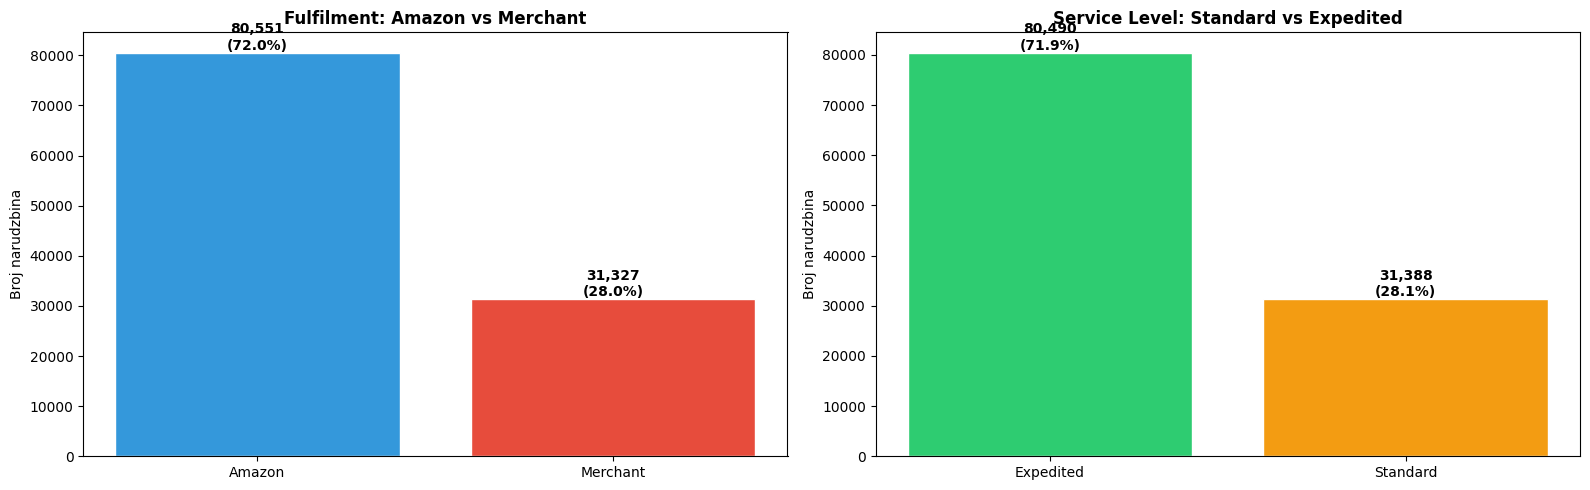

Prosecan Amount po Fulfilment:
  Amazon    : 662 INR
  Merchant  : 667 INR

Prosecan Amount po Service Level:
  Expedited : 662 INR
  Standard  : 667 INR


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Fulfilment
ful_counts = df['Fulfilment'].value_counts()
bars1 = axes[0].bar(ful_counts.index, ful_counts.values, color=['#3498db', '#e74c3c'], edgecolor='white')
axes[0].set_title('Fulfilment: Amazon vs Merchant', fontweight='bold')
axes[0].set_ylabel('Broj narudzbina')
for bar, val in zip(bars1, ful_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Ship-service-level
ssl_counts = df['ship-service-level'].value_counts()
bars2 = axes[1].bar(ssl_counts.index, ssl_counts.values, color=['#2ecc71', '#f39c12'], edgecolor='white')
axes[1].set_title('Service Level: Standard vs Expedited', fontweight='bold')
axes[1].set_ylabel('Broj narudzbina')
for bar, val in zip(bars2, ssl_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Prosecan Amount po Fulfilment i Service Level
print("Prosecan Amount po Fulfilment:")
for f_type in ful_counts.index:
    avg = df[df['Fulfilment'] == f_type]['Amount'].mean()
    print(f"  {f_type:10s}: {avg:.0f} INR")

print("\nProsecan Amount po Service Level:")
for sl in ssl_counts.index:
    avg = df[df['ship-service-level'] == sl]['Amount'].mean()
    print(f"  {sl:10s}: {avg:.0f} INR")

#### Distribucija velicine (Size)

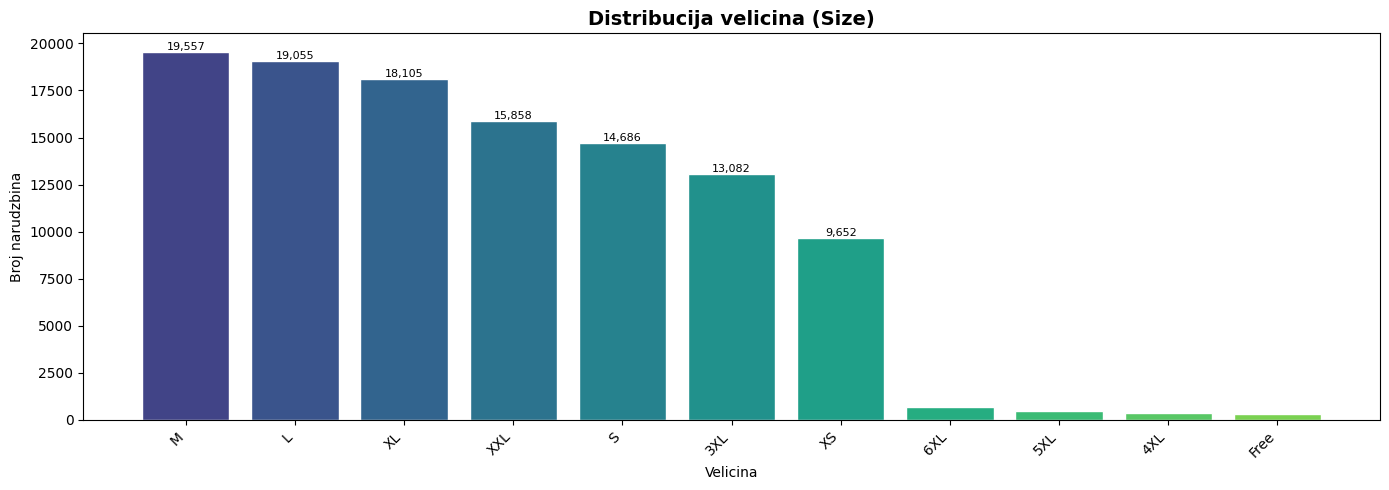

Top 10 velicina:
  M         : 19,557 (17.5%)
  L         : 19,055 (17.0%)
  XL        : 18,105 (16.2%)
  XXL       : 15,858 (14.2%)
  S         : 14,686 (13.1%)
  3XL       : 13,082 (11.7%)
  XS        :  9,652 (8.6%)
  6XL       :    666 (0.6%)
  5XL       :    499 (0.4%)
  4XL       :    385 (0.3%)

  Ukupno razlicitih velicina: 11


In [23]:
size_counts = df['Size'].value_counts()

plt.figure(figsize=(14, 5))
bars = plt.bar(range(len(size_counts)), size_counts.values,
               color=plt.cm.viridis(np.linspace(0.2, 0.8, len(size_counts))),
               edgecolor='white')
plt.xticks(range(len(size_counts)), size_counts.index, rotation=45, ha='right')
plt.title('Distribucija velicina (Size)', fontsize=14, fontweight='bold')
plt.xlabel('Velicina')
plt.ylabel('Broj narudzbina')

for bar, val in zip(bars, size_counts.values):
    if val > len(df) * 0.02:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("Top 10 velicina:")
for size, cnt in size_counts.head(10).items():
    print(f"  {size:10s}: {cnt:>6,} ({cnt/len(df)*100:.1f}%)")
print(f"\n  Ukupno razlicitih velicina: {df['Size'].nunique()}")

#### Geografska distribucija (Top drzave)

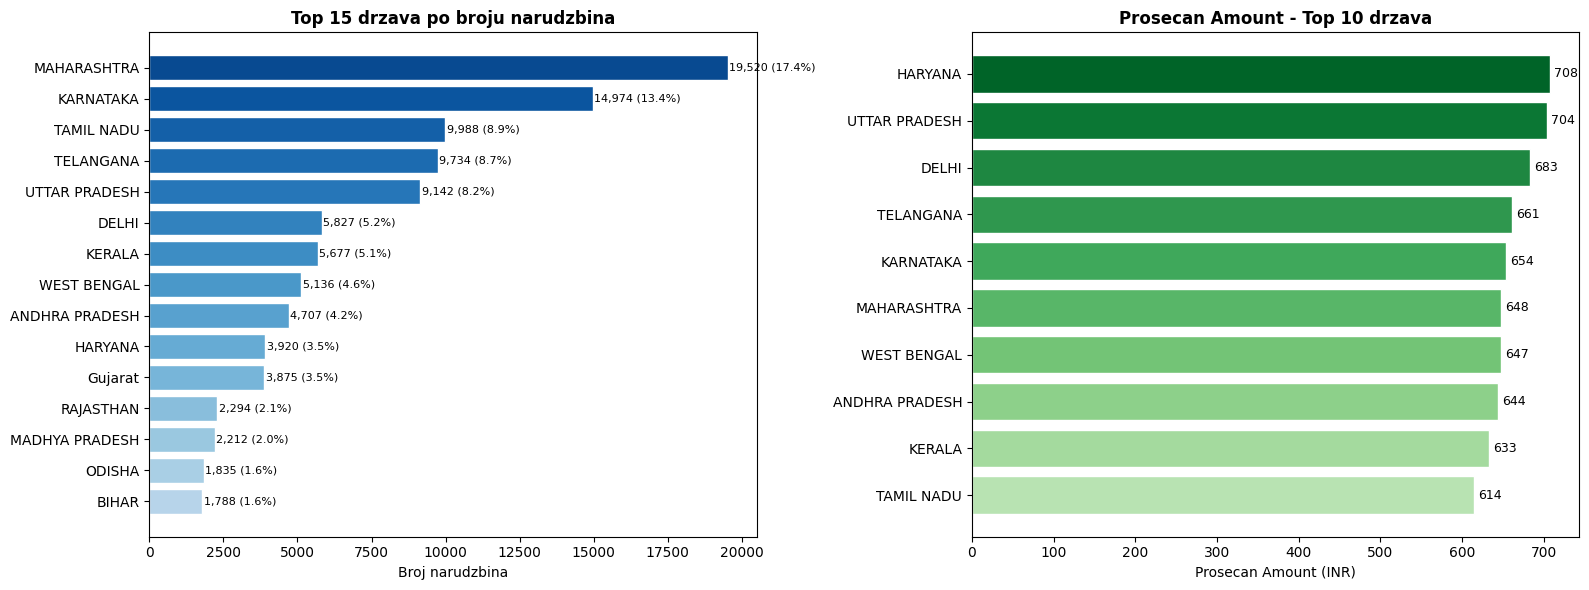

Geografske statistike:
  Ukupno drzava:  68
  Ukupno gradova: 8492
  Top 3 drzave cine 39.8% svih narudzbina


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 ship-state po broju narudzbina
state_counts = df['ship-state'].value_counts().head(15)
bars = axes[0].barh(state_counts.index[::-1], state_counts.values[::-1],
                     color=plt.cm.Blues(np.linspace(0.3, 0.9, len(state_counts))),
                     edgecolor='white')
axes[0].set_title('Top 15 drzava po broju narudzbina', fontweight='bold')
axes[0].set_xlabel('Broj narudzbina')
for bar, val in zip(bars, state_counts.values[::-1]):
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{val:,} ({val/len(df)*100:.1f}%)', va='center', fontsize=8)

# Prosecan Amount po Top 10 drzava
top_states = df['ship-state'].value_counts().head(10).index
state_avg = df[df['ship-state'].isin(top_states)].groupby('ship-state')['Amount'].mean().sort_values(ascending=True)
bars2 = axes[1].barh(state_avg.index, state_avg.values,
                      color=plt.cm.Greens(np.linspace(0.3, 0.9, len(state_avg))),
                      edgecolor='white')
axes[1].set_title('Prosecan Amount - Top 10 drzava', fontweight='bold')
axes[1].set_xlabel('Prosecan Amount (INR)')
for bar, val in zip(bars2, state_avg.values):
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{val:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Geografske statistike:")
print(f"  Ukupno drzava:  {df['ship-state'].nunique()}")
print(f"  Ukupno gradova: {df['ship-city'].nunique()}")
top3 = df['ship-state'].value_counts().head(3)
print(f"  Top 3 drzave cine {top3.sum()/len(df)*100:.1f}% svih narudzbina")

#### Encoding

In [25]:
cat_cols = ['Category', 'Status', 'Fulfilment', 'ship-service-level', 'Size']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_encoded = encoder.fit_transform(df[cat_cols])

cat_encoded_df = pd.DataFrame(
    cat_encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=df.index
)

df['B2B_encoded'] = df['B2B'].astype(int)

num_cols = ['Amount', 'Qty', 'Revenue', 'Amount_log', 'Month']
df_encoded = pd.concat([df[num_cols], df[['B2B_encoded']], cat_encoded_df], axis=1)

print(f"Shape pre encodinga:  {df.shape}")
print(f"Shape posle encodinga: {df_encoded.shape}")
print(f"\nKolone u df_encoded ({len(df_encoded.columns)}):")
print(list(df_encoded.columns))


Shape pre encodinga:  (111878, 18)
Shape posle encodinga: (111878, 42)

Kolone u df_encoded (42):
['Amount', 'Qty', 'Revenue', 'Amount_log', 'Month', 'B2B_encoded', 'Category_Blouse', 'Category_Bottom', 'Category_Dupatta', 'Category_Ethnic Dress', 'Category_Saree', 'Category_Set', 'Category_Top', 'Category_Western Dress', 'Category_kurta', 'Status_Cancelled', 'Status_Pending', 'Status_Pending - Waiting for Pick Up', 'Status_Shipped', 'Status_Shipped - Damaged', 'Status_Shipped - Delivered to Buyer', 'Status_Shipped - Lost in Transit', 'Status_Shipped - Out for Delivery', 'Status_Shipped - Picked Up', 'Status_Shipped - Rejected by Buyer', 'Status_Shipped - Returned to Seller', 'Status_Shipped - Returning to Seller', 'Fulfilment_Amazon', 'Fulfilment_Merchant', 'ship-service-level_Expedited', 'ship-service-level_Standard', 'Size_3XL', 'Size_4XL', 'Size_5XL', 'Size_6XL', 'Size_Free', 'Size_L', 'Size_M', 'Size_S', 'Size_XL', 'Size_XS', 'Size_XXL']


#### Korelaciona Mapa

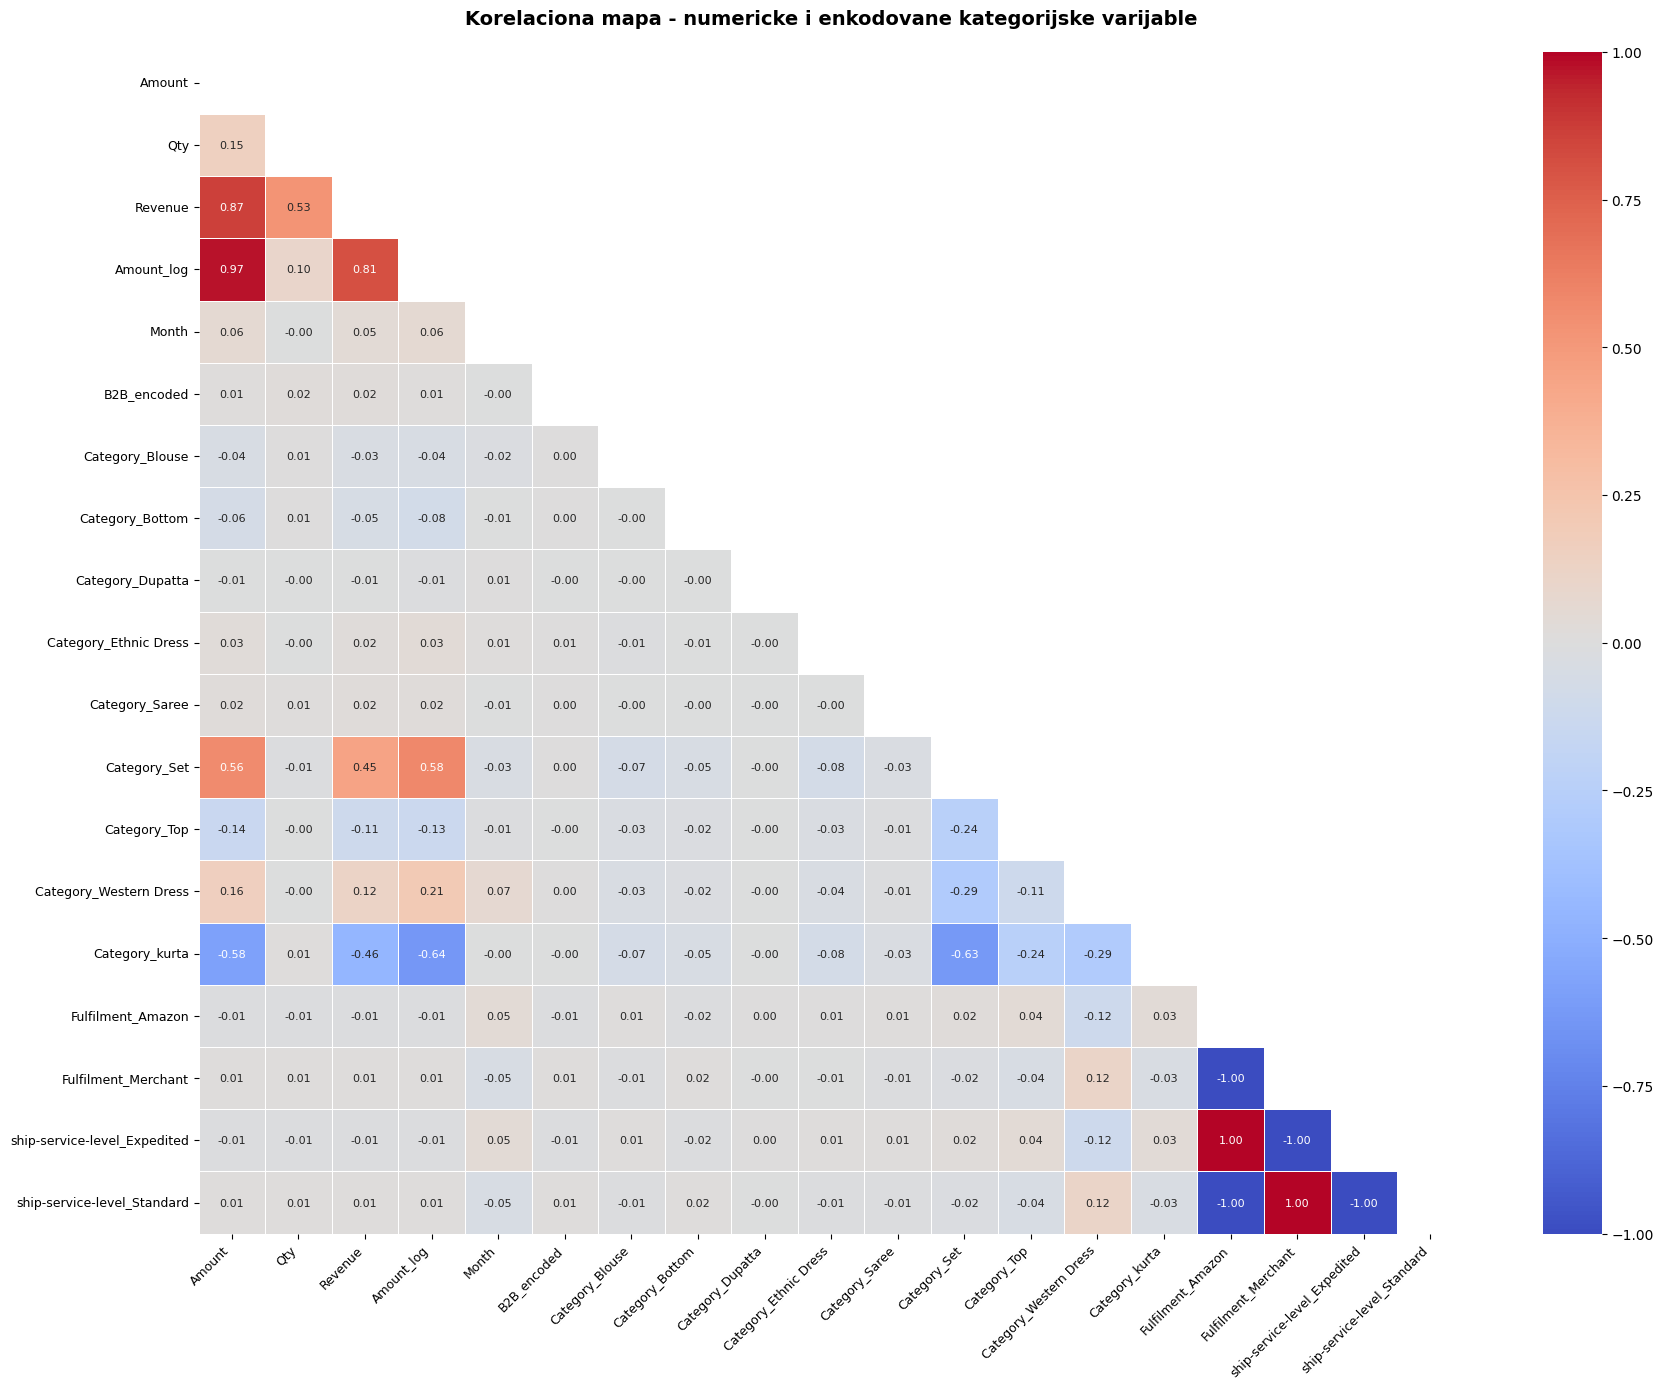

In [26]:
corr_features = ['Amount', 'Qty', 'Revenue', 'Amount_log', 'Month', 'B2B_encoded']

top_encoded = [c for c in df_encoded.columns if
           c.startswith('Category_') or
           c.startswith('Fulfilment_') or
           c.startswith('ship-service-level_')]
corr_features += top_encoded

df_corr = df_encoded[corr_features].copy()
corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(18, 14))

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sb.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 8}
)

ax.set_title(
    "Korelaciona mapa - numericke i enkodovane kategorijske varijable",
    fontsize=14, fontweight="bold", pad=20
)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## Klasterizacija

### Priprema podataka za klasterovanje

In [27]:
drop_cols = [
    'Amount',
    'Revenue',
    'Fulfilment_Merchant',
    'ship-service-level_Standard'
]

df_model = df_encoded.drop(columns=drop_cols)

print(f"Shape pre uklanjanja: {df_encoded.shape}")
print(f"Shape posle uklanjanja: {df_model.shape}")
print(f"\nUklonjene {len(drop_cols)} redundantne kolone: {drop_cols}")

Shape pre uklanjanja: (111878, 42)
Shape posle uklanjanja: (111878, 38)

Uklonjene 4 redundantne kolone: ['Amount', 'Revenue', 'Fulfilment_Merchant', 'ship-service-level_Standard']


### Skaliranje

In [28]:
scaler = RobustScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_model),
    columns=df_model.columns,
    index=df_model.index
)

print(f"df_scaled shape: {df_scaled.shape}")
print(f"Statistike nakon skaliranja:")
print(df_scaled[['Amount_log', 'Qty', 'Month', 'B2B_encoded']].describe().round(3))

df_scaled shape: (111878, 38)
Statistike nakon skaliranja:
       Amount_log         Qty       Month  B2B_encoded
count  111878.000  111878.000  111878.000   111878.000
mean       -0.023       0.004      -0.043        0.007
std         0.720       0.074       0.409        0.085
min        -2.106       0.000      -1.000        0.000
25%        -0.562       0.000      -0.500        0.000
50%         0.000       0.000       0.000        0.000
75%         0.438       0.000       0.500        0.000
max         4.065       7.000       0.500        1.000


### K-Means Klasterizacija

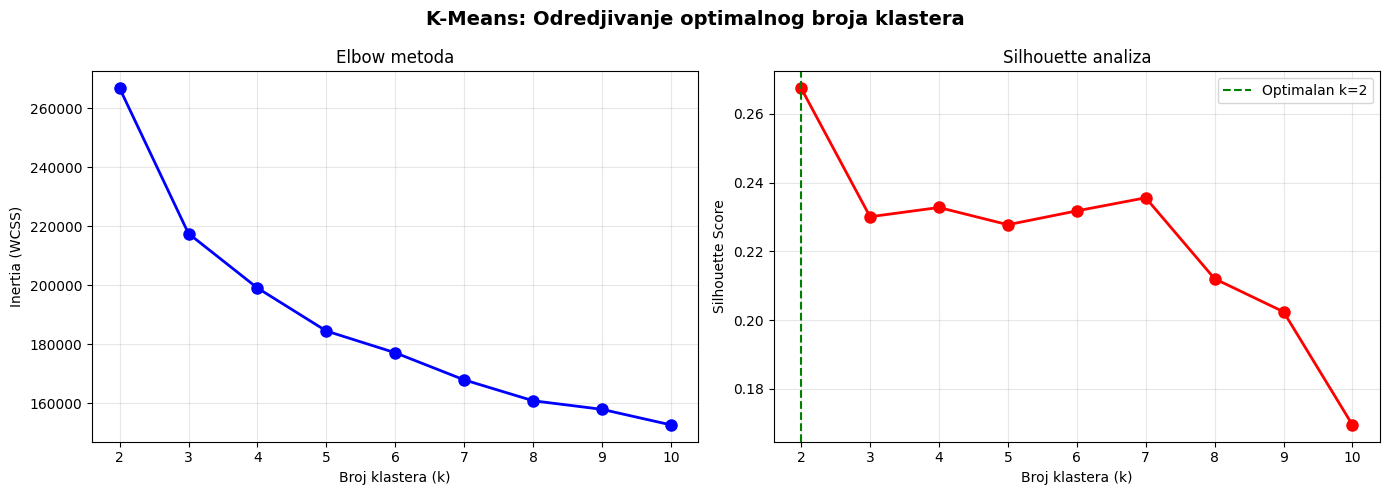

  k=2: 0.2675 <--
  k=3: 0.2301
  k=4: 0.2328
  k=5: 0.2277
  k=6: 0.2318
  k=7: 0.2356
  k=8: 0.2120
  k=9: 0.2024
  k=10: 0.1695


In [29]:
K_range = range(2, 11)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(df_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Broj klastera (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow metoda')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, sil_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Broj klastera (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette analiza')
axes[1].grid(True, alpha=0.3)

best_k = list(K_range)[np.argmax(sil_scores)]
axes[1].axvline(x=best_k, color='green', linestyle='--', label=f'Optimalan k={best_k}')
axes[1].legend()

plt.suptitle('K-Means: Odredjivanje optimalnog broja klastera', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

for k, s in zip(K_range, sil_scores):
    marker = " <--" if k == best_k else ""
    print(f"  k={k}: {s:.4f}{marker}")

In [30]:
optimal_k = best_k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans_final.fit_predict(df_scaled)

print(f"K-Means (k={optimal_k}):")
print(df['KMeans_Cluster'].value_counts().sort_index())

K-Means (k=2):
KMeans_Cluster
0    31328
1    80550
Name: count, dtype: int64


### DBSCAN Klasterizacija

DBSCAN je algoritam zasnovan na gustini koji automatski odredjuje broj klastera. Medjutim, na visokodimenzionalnim podacima moze imati problema jer rastojanja izmedju tacaka postaju uniformna. Testiramo ga ovde, a kasnije i na PCA-redukovanim podacima.

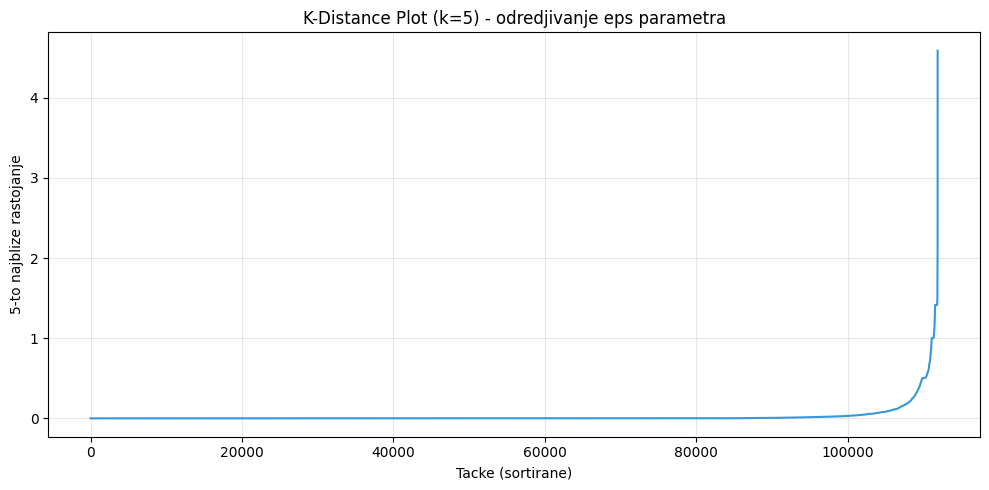

  90. percentil rastojanja: 0.035
  95. percentil rastojanja: 0.115
  97. percentil rastojanja: 0.247
  99. percentil rastojanja: 0.666


In [31]:
k = 5
nn = NearestNeighbors(n_neighbors=k)
nn.fit(df_scaled)
distances, _ = nn.kneighbors(df_scaled)
distances = np.sort(distances[:, k-1])

plt.figure(figsize=(10, 5))
plt.plot(distances, color='#3498db', linewidth=1.5)
plt.xlabel('Tacke (sortirane)')
plt.ylabel(f'{k}-to najblize rastojanje')
plt.title(f'K-Distance Plot (k={k}) - odredjivanje eps parametra')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for p in [90, 95, 97, 99]:
    print(f"  {p}. percentil rastojanja: {np.percentile(distances, p):.3f}")

In [ ]:
np.random.seed(42)
# koristimo uzorak od 15k tacaka
dbscan_sample_size = 15000
dbscan_idx = np.random.choice(len(df_scaled), size=dbscan_sample_size, replace=False)
df_scaled_sample = df_scaled.iloc[dbscan_idx].values

eps_values = [3.0, 4.0, 5.0, 6.0]
min_samples_values = [5, 10, 20]
dbscan_results = []

for eps in eps_values:
    for ms in min_samples_values:
        dbs = DBSCAN(eps=eps, min_samples=ms)
        labels = dbs.fit_predict(df_scaled_sample)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        noise_pct = n_noise / len(labels) * 100
        if n_clusters >= 2:
            sil = silhouette_score(df_scaled_sample, labels)
        else:
            sil = -1
        dbscan_results.append({
            'eps': eps, 'min_samples': ms,
            'n_clusters': n_clusters, 'noise_pct': round(noise_pct, 1),
            'silhouette': round(sil, 4)
        })
        print(f"  eps={eps}, ms={ms} -> {n_clusters} klastera, {noise_pct:.1f}% noise")

dbscan_df = pd.DataFrame(dbscan_results)
print(f"\nRezultati pretrage (uzorak {dbscan_sample_size}):")
print(dbscan_df.to_string(index=False))

valid = dbscan_df[(dbscan_df['n_clusters'] >= 2) & (dbscan_df['noise_pct'] < 30)]
if len(valid) > 0:
    best_db = valid.loc[valid['silhouette'].idxmax()]
else:
    best_db = dbscan_df.loc[dbscan_df['silhouette'].idxmax()]
print(f"\nIzabrano: eps={best_db['eps']}, min_samples={int(best_db['min_samples'])}")

  eps=3.0, ms=5 -> 1 klastera, 0.0% noise
  eps=3.0, ms=10 -> 1 klastera, 0.0% noise
  eps=3.0, ms=20 -> 1 klastera, 0.0% noise
  eps=4.0, ms=5 -> 1 klastera, 0.0% noise
  eps=4.0, ms=10 -> 1 klastera, 0.0% noise
  eps=4.0, ms=20 -> 1 klastera, 0.0% noise
  eps=5.0, ms=5 -> 1 klastera, 0.0% noise
  eps=5.0, ms=10 -> 1 klastera, 0.0% noise
  eps=5.0, ms=20 -> 1 klastera, 0.0% noise
  eps=6.0, ms=5 -> 1 klastera, 0.0% noise
  eps=6.0, ms=10 -> 1 klastera, 0.0% noise
  eps=6.0, ms=20 -> 1 klastera, 0.0% noise

Rezultati pretrage (uzorak 15000):
 eps  min_samples  n_clusters  noise_pct  silhouette
 3.0            5           1        0.0          -1
 3.0           10           1        0.0          -1
 3.0           20           1        0.0          -1
 4.0            5           1        0.0          -1
 4.0           10           1        0.0          -1
 4.0           20           1        0.0          -1
 5.0            5           1        0.0          -1
 5.0           10           

In [33]:
np.random.seed(42)
dbscan_full_sample = 20000
dbscan_full_idx = np.random.choice(len(df_scaled), size=dbscan_full_sample, replace=False)
df_scaled_dbscan = df_scaled.iloc[dbscan_full_idx].values

dbscan_final = DBSCAN(eps=best_db['eps'], min_samples=int(best_db['min_samples']))
sample_labels = dbscan_final.fit_predict(df_scaled_dbscan)

n_clusters_found = len(set(sample_labels)) - (1 if -1 in sample_labels else 0)
print(f"Klasteri: {n_clusters_found}, noise: {(sample_labels == -1).sum()}")

if n_clusters_found >= 2:
    non_noise_mask = sample_labels != -1
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(df_scaled_dbscan[non_noise_mask], sample_labels[non_noise_mask])
    df['DBSCAN_Cluster'] = knn.predict(df_scaled.values)
else:
    # DBSCAN nije razdvojio klastere na 38D podacima - ocekivano ponasanje
    df['DBSCAN_Cluster'] = 0

print(df['DBSCAN_Cluster'].value_counts().sort_index())

Klasteri: 1, noise: 0
DBSCAN_Cluster
0    111878
Name: count, dtype: int64


### Hijerarhijska Klasterizacija

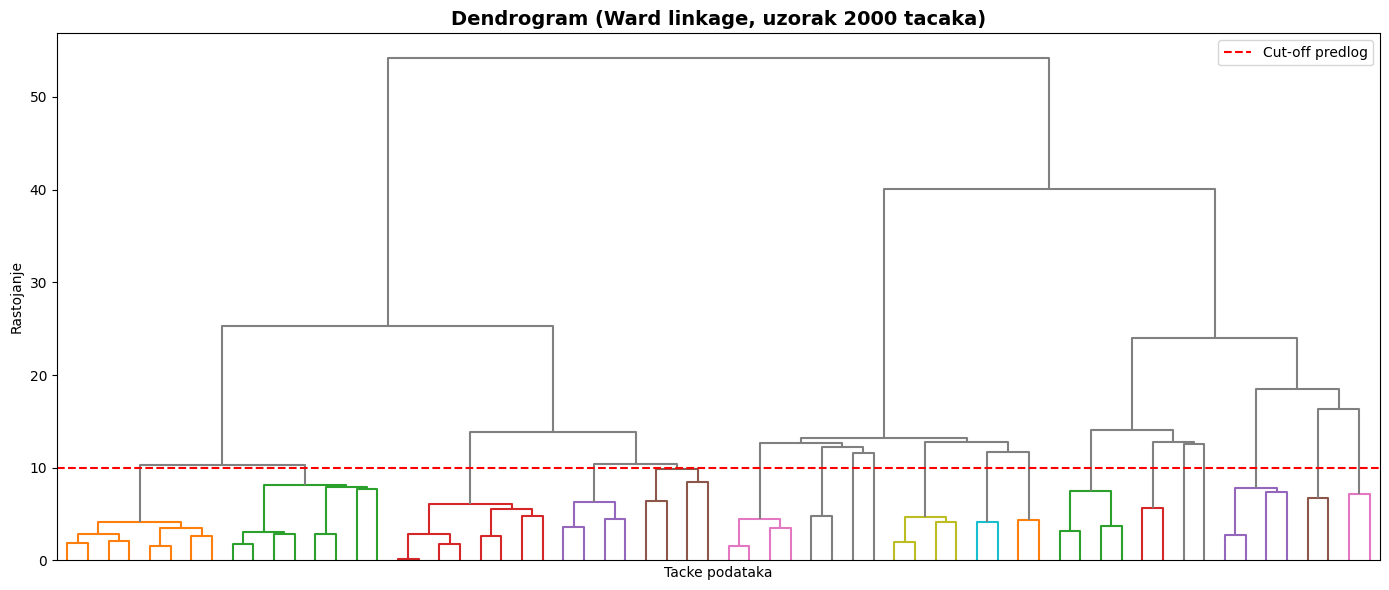

In [ ]:
np.random.seed(42)
sample_size = min(2000, len(df_scaled))
sample_idx = np.random.choice(len(df_scaled), size=sample_size, replace=False)
X_sample = df_scaled.iloc[sample_idx].values

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='level', p=5, color_threshold=10,
           no_labels=True, above_threshold_color='gray')
plt.title('Dendrogram (Ward linkage, uzorak 2000 tacaka)', fontsize=14, fontweight='bold')
plt.xlabel('Tacke podataka')
plt.ylabel('Rastojanje')
plt.axhline(y=10, color='red', linestyle='--', label='Cut-off predlog')
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
np.random.seed(42)
agg_sample_size = 20000
agg_idx = np.random.choice(len(df_scaled), size=agg_sample_size, replace=False)
df_scaled_agg_sample = df_scaled.iloc[agg_idx].values

agg_sils = []
for k in range(2, 8):
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(df_scaled_agg_sample)
    sil = silhouette_score(df_scaled_agg_sample, labels)
    agg_sils.append({'k': k, 'silhouette': round(sil, 4)})
    print(f"  k={k}: silhouette={sil:.4f}")

agg_df = pd.DataFrame(agg_sils)
best_agg_k = agg_df.loc[agg_df['silhouette'].idxmax(), 'k']
print(f"\nNajbolji k: {best_agg_k}")

agg_final = AgglomerativeClustering(n_clusters=int(best_agg_k), linkage='ward')
sample_labels = agg_final.fit_predict(df_scaled_agg_sample)

knn_agg = KNeighborsClassifier(n_neighbors=5)
knn_agg.fit(df_scaled_agg_sample, sample_labels)
df['Agg_Cluster'] = knn_agg.predict(df_scaled.values)

print(f"\nAgglomerative (k={int(best_agg_k)}):")
print(df['Agg_Cluster'].value_counts().sort_index())

  k=2: silhouette=0.2675
  k=3: silhouette=0.2033
  k=4: silhouette=0.2061
  k=5: silhouette=0.2141
  k=6: silhouette=0.2218
  k=7: silhouette=0.2242

Najbolji k: 2

Agglomerative (k=2):
Agg_Cluster
0    80552
1    31326
Name: count, dtype: int64


### Gaussian Mixture Model

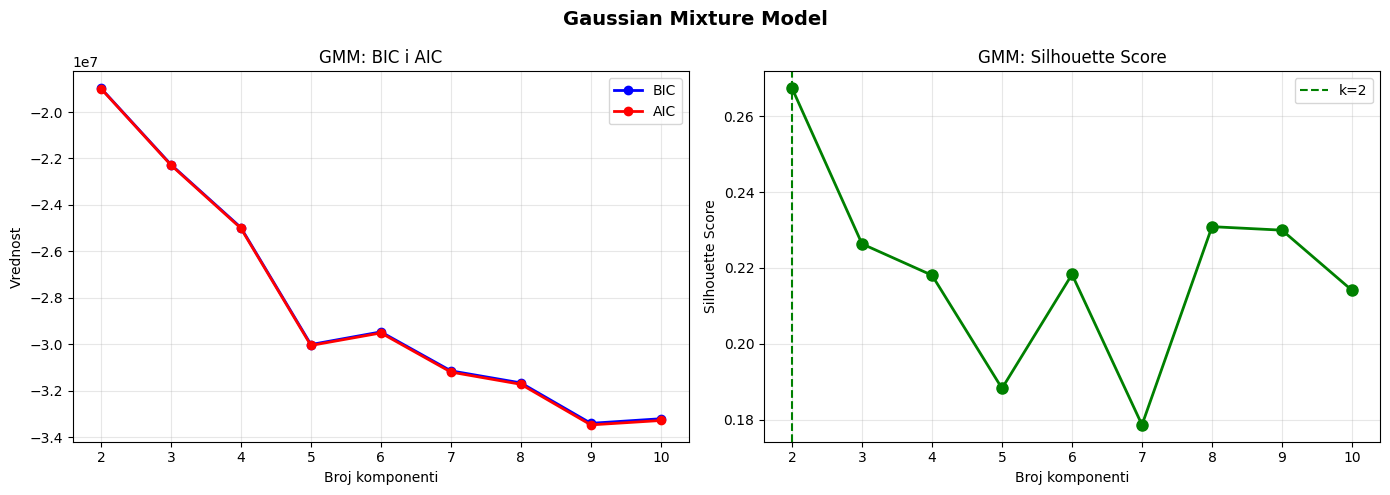

Silhouette -> k=2
BIC -> k=9


In [36]:
bics, aics, gmm_sils = [], [], []

for k in range(2, 11):
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5)
    gmm.fit(df_scaled)
    labels = gmm.predict(df_scaled)
    bics.append(gmm.bic(df_scaled.values))
    aics.append(gmm.aic(df_scaled.values))
    gmm_sils.append(silhouette_score(df_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(2, 11), bics, 'bo-', label='BIC', linewidth=2)
axes[0].plot(range(2, 11), aics, 'ro-', label='AIC', linewidth=2)
axes[0].set_xlabel('Broj komponenti')
axes[0].set_ylabel('Vrednost')
axes[0].set_title('GMM: BIC i AIC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(2, 11), gmm_sils, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Broj komponenti')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('GMM: Silhouette Score')
axes[1].grid(True, alpha=0.3)

best_gmm_k = range(2, 11)[np.argmax(gmm_sils)]
axes[1].axvline(x=best_gmm_k, color='green', linestyle='--', label=f'k={best_gmm_k}')
axes[1].legend()

plt.suptitle('Gaussian Mixture Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Silhouette -> k={best_gmm_k}")
print(f"BIC -> k={range(2, 11)[np.argmin(bics)]}")

In [37]:
gmm_final = GaussianMixture(n_components=best_gmm_k, random_state=42, n_init=5)
gmm_final.fit(df_scaled)
df['GMM_Cluster'] = gmm_final.predict(df_scaled)
df['GMM_Confidence'] = gmm_final.predict_proba(df_scaled.values).max(axis=1)

print(f"GMM (k={best_gmm_k}):")
print(df['GMM_Cluster'].value_counts().sort_index())
print(f"\nPouzdanost dodele: mean={df['GMM_Confidence'].mean():.4f}, min={df['GMM_Confidence'].min():.4f}")

GMM (k=2):
GMM_Cluster
0    31327
1    80551
Name: count, dtype: int64

Pouzdanost dodele: mean=1.0000, min=1.0000


### Poredjenje algoritama

Poredimo rezultate koristeci Silhouette, Calinski-Harabasz i Davies-Bouldin metrike.

In [38]:
algorithms = {
    'K-Means': df['KMeans_Cluster'],
    'DBSCAN': df['DBSCAN_Cluster'],
    'Agglomerative': df['Agg_Cluster'],
    'GMM': df['GMM_Cluster']
}

comparison = []
for name, labels in algorithms.items():
    if name == 'DBSCAN':
        mask = labels != -1
        if mask.sum() < 10 or len(labels[mask].unique()) < 2:
            comparison.append({'Algoritam': name, 'Br. klastera': 0,
                'Silhouette': 'N/A', 'Calinski-Harabasz': 'N/A',
                'Davies-Bouldin': 'N/A', 'Noise (%)': f"{(~mask).sum()/len(labels)*100:.1f}%"})
            continue
        X_ev = df_scaled[mask].values
        lab_ev = labels[mask].values
    else:
        X_ev = df_scaled.values
        lab_ev = labels.values

    sil = silhouette_score(X_ev, lab_ev)
    ch = calinski_harabasz_score(X_ev, lab_ev)
    db = davies_bouldin_score(X_ev, lab_ev)
    n_cl = len(set(lab_ev))
    noise = f"{(labels == -1).sum()/len(labels)*100:.1f}%" if name == 'DBSCAN' else '-'

    comparison.append({'Algoritam': name, 'Br. klastera': n_cl,
        'Silhouette': round(sil, 4), 'Calinski-Harabasz': round(ch, 2),
        'Davies-Bouldin': round(db, 4), 'Noise (%)': noise})

comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))

    Algoritam  Br. klastera Silhouette Calinski-Harabasz Davies-Bouldin Noise (%)
      K-Means             2     0.2675          34721.23         1.5966         -
       DBSCAN             0        N/A               N/A            N/A      0.0%
Agglomerative             2     0.2675          34719.93         1.5966         -
          GMM             2     0.2675          34721.18         1.5966         -


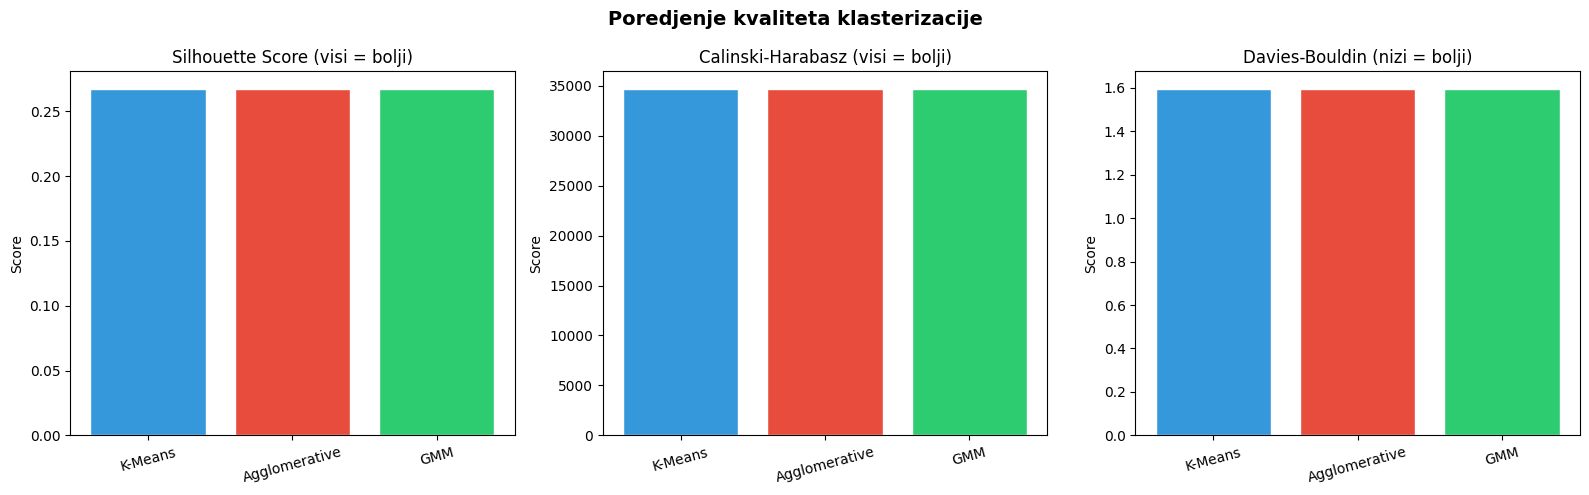

In [39]:
comp_num = comparison_df[comparison_df['Silhouette'] != 'N/A'].copy()
for col in ['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin']:
    comp_num[col] = comp_num[col].astype(float)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6'][:len(comp_num)]

axes[0].bar(comp_num['Algoritam'], comp_num['Silhouette'], color=colors, edgecolor='white')
axes[0].set_title('Silhouette Score (visi = bolji)')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(comp_num['Algoritam'], comp_num['Calinski-Harabasz'], color=colors, edgecolor='white')
axes[1].set_title('Calinski-Harabasz (visi = bolji)')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(comp_num['Algoritam'], comp_num['Davies-Bouldin'], color=colors, edgecolor='white')
axes[2].set_title('Davies-Bouldin (nizi = bolji)')
axes[2].set_ylabel('Score')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Poredjenje kvaliteta klasterizacije', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Zapazanje

Svi algoritmi (osim DBSCAN-a) daju prakticno iste rezultate: k=2, Silhouette~0.267, identicna podela (~31k vs ~80k). DBSCAN uopste nije uspeo da razdvoji klastere.

Razlog: dataset ima 38 dimenzija (vecina od OneHotEncoding-a), sto znaci da rastojanja izmedju tacaka postaju uniformna u visokom prostoru.

**Resenje:** Primena PCA redukcije dimenzionalnosti pre klasterizacije, cime se uklanja sum iz OHE kolona i fokusira na stvarnu varijansu u podacima.

## Redukcija dimenzionalnosti

### PCA (Principal Component Analysis)

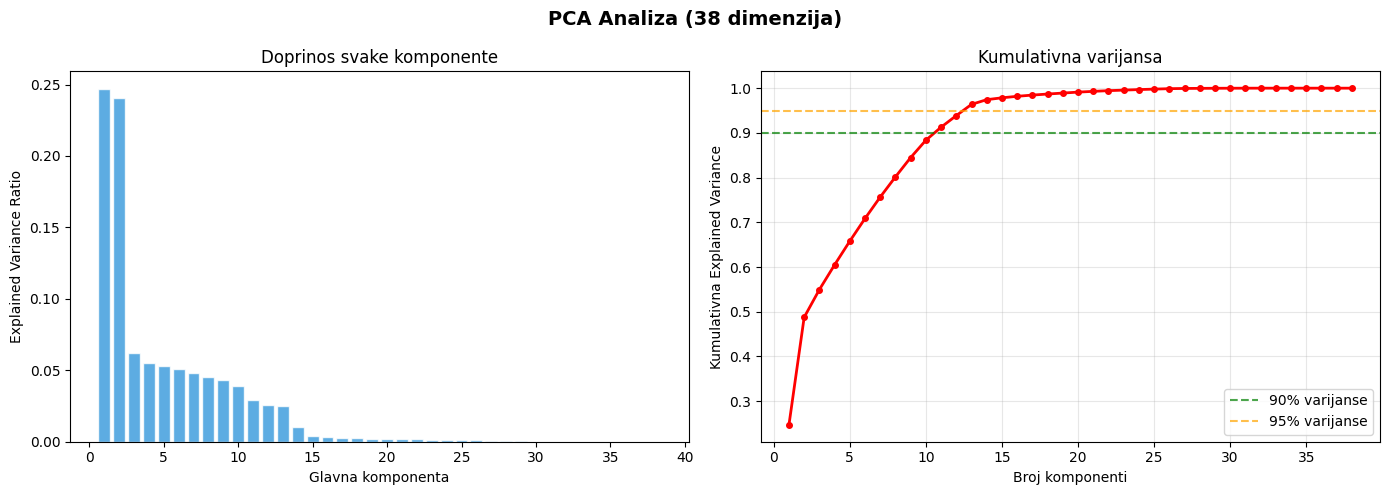

Za 90% varijanse: 11 komponenti
Za 95% varijanse: 13 komponenti
  PC1: 24.7% (kumulativno: 24.7%)
  PC2: 24.1% (kumulativno: 48.8%)
  PC3: 6.2% (kumulativno: 54.9%)
  PC4: 5.5% (kumulativno: 60.5%)
  PC5: 5.3% (kumulativno: 65.8%)
  PC6: 5.1% (kumulativno: 70.9%)
  PC7: 4.8% (kumulativno: 75.7%)
  PC8: 4.5% (kumulativno: 80.2%)
  PC9: 4.3% (kumulativno: 84.5%)
  PC10: 3.9% (kumulativno: 88.4%)


In [40]:
pca_full = PCA(random_state=42)
pca_full.fit(df_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained)+1), explained, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Glavna komponenta')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Doprinos svake komponente')

axes[1].plot(range(1, len(cumulative)+1), cumulative, 'ro-', linewidth=2, markersize=4)
axes[1].axhline(y=0.90, color='green', linestyle='--', alpha=0.7, label='90% varijanse')
axes[1].axhline(y=0.95, color='orange', linestyle='--', alpha=0.7, label='95% varijanse')
axes[1].set_xlabel('Broj komponenti')
axes[1].set_ylabel('Kumulativna Explained Variance')
axes[1].set_title('Kumulativna varijansa')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA Analiza (38 dimenzija)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

n_comp_90 = np.argmax(cumulative >= 0.90) + 1
n_comp_95 = np.argmax(cumulative >= 0.95) + 1

print(f"Za 90% varijanse: {n_comp_90} komponenti")
print(f"Za 95% varijanse: {n_comp_95} komponenti")

for i in range(min(10, len(explained))):
    print(f"  PC{i+1}: {explained[i]*100:.1f}% (kumulativno: {cumulative[i]*100:.1f}%)")

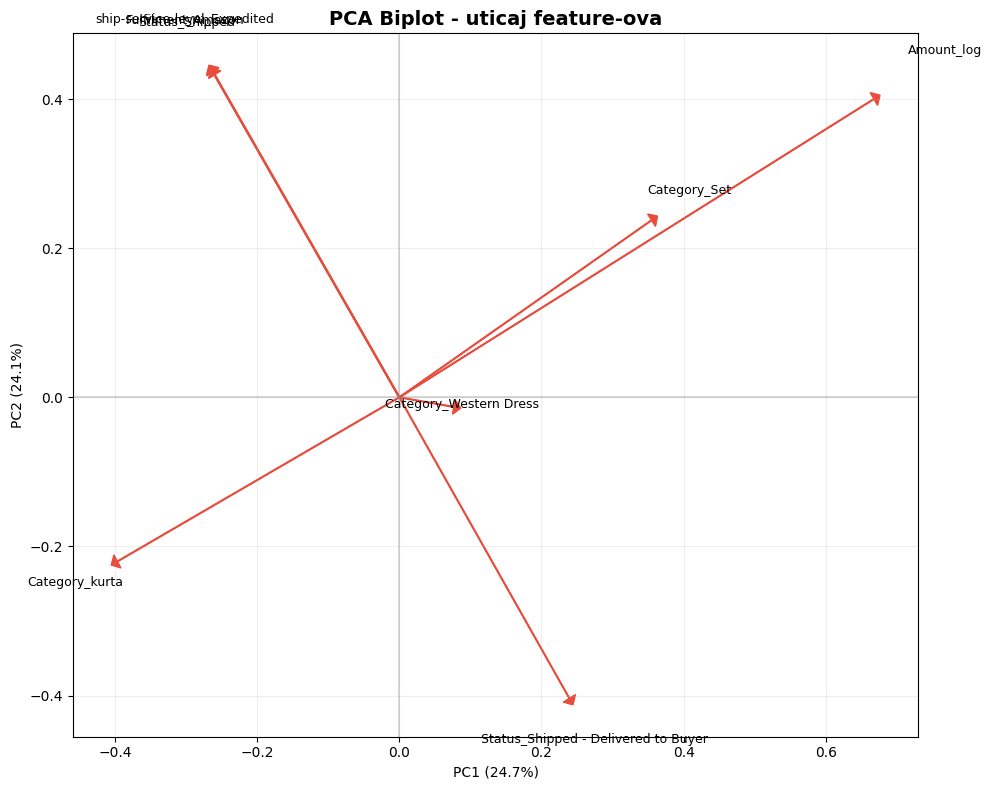

Najuticajniji feature-ovi na PC1:
Amount_log                             0.6679
Category_kurta                         0.3967
Category_Set                           0.3550
Fulfilment_Amazon                      0.2626
ship-service-level_Expedited           0.2625
Status_Shipped                         0.2599
Status_Shipped - Delivered to Buyer    0.2393
Category_Western Dress                 0.0765
Category_Top                           0.0317
Size_XXL                               0.0188


In [41]:
# koji feature-ovi najvise uticu na PC1 i PC2
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(df_scaled)

loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=df_scaled.columns
)

top_features = loadings.apply(lambda x: x.abs()).max(axis=1).nlargest(8).index

plt.figure(figsize=(10, 8))
for feat in top_features:
    plt.arrow(0, 0, loadings.loc[feat, 'PC1'], loadings.loc[feat, 'PC2'],
              head_width=0.02, head_length=0.01, fc='#e74c3c', ec='#e74c3c')
    plt.text(loadings.loc[feat, 'PC1']*1.15, loadings.loc[feat, 'PC2']*1.15,
             feat, fontsize=9, ha='center')

plt.xlabel(f'PC1 ({explained[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained[1]*100:.1f}%)')
plt.title('PCA Biplot - uticaj feature-ova', fontsize=14, fontweight='bold')
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("Najuticajniji feature-ovi na PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(10).round(4).to_string())

### Klasterizacija na PCA-redukovanim podacima

Posto smo videli da podaci daju lose rezultate, redukujemo dimenzije PCA-om i ponavljamo klasterizaciju.

In [42]:
pca_red = PCA(n_components=n_comp_95, random_state=42)
X_pca = pca_red.fit_transform(df_scaled)

print(f"Redukcija: {df_scaled.shape[1]}D -> {n_comp_95}D ({cumulative[n_comp_95-1]*100:.1f}% varijanse)")

Redukcija: 38D -> 13D (96.4% varijanse)


#### K-Means na PCA podacima

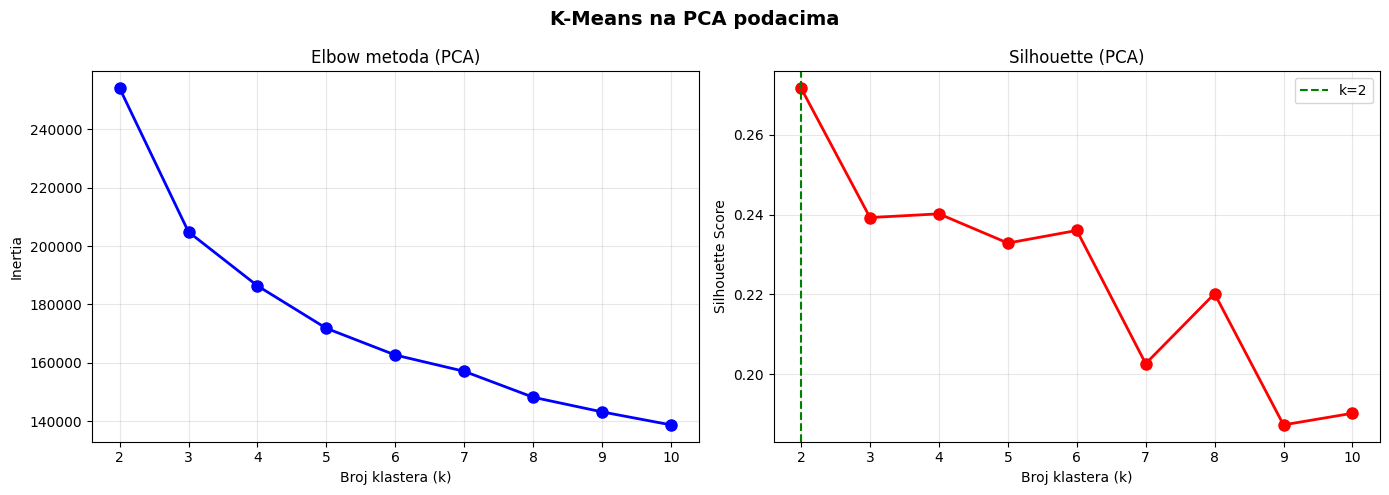

  k=2: 0.2717 <--
  k=3: 0.2392
  k=4: 0.2402
  k=5: 0.2329
  k=6: 0.2360
  k=7: 0.2026
  k=8: 0.2202
  k=9: 0.1873
  k=10: 0.1902


In [43]:
K_range = range(2, 11)
inertias_pca = []
sil_pca = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias_pca.append(km.inertia_)
    sil_pca.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias_pca, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Broj klastera (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow metoda (PCA)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, sil_pca, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Broj klastera (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette (PCA)')
axes[1].grid(True, alpha=0.3)

best_k_pca = list(K_range)[np.argmax(sil_pca)]
axes[1].axvline(x=best_k_pca, color='green', linestyle='--', label=f'k={best_k_pca}')
axes[1].legend()

plt.suptitle('K-Means na PCA podacima', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

for k, s in zip(K_range, sil_pca):
    marker = " <--" if k == best_k_pca else ""
    print(f"  k={k}: {s:.4f}{marker}")

In [44]:
optimal_k_pca = best_k_pca
km_pca = KMeans(n_clusters=optimal_k_pca, random_state=42, n_init=10)
df['KMeans_PCA'] = km_pca.fit_predict(X_pca)

print(f"K-Means PCA (k={optimal_k_pca}):")
print(df['KMeans_PCA'].value_counts().sort_index())

K-Means PCA (k=2):
KMeans_PCA
0    31328
1    80550
Name: count, dtype: int64


#### DBSCAN na PCA podacima

Na redukovanim podacima rastojanja su smislenija, pa DBSCAN ima vecu sansu da razdvoji klastere.

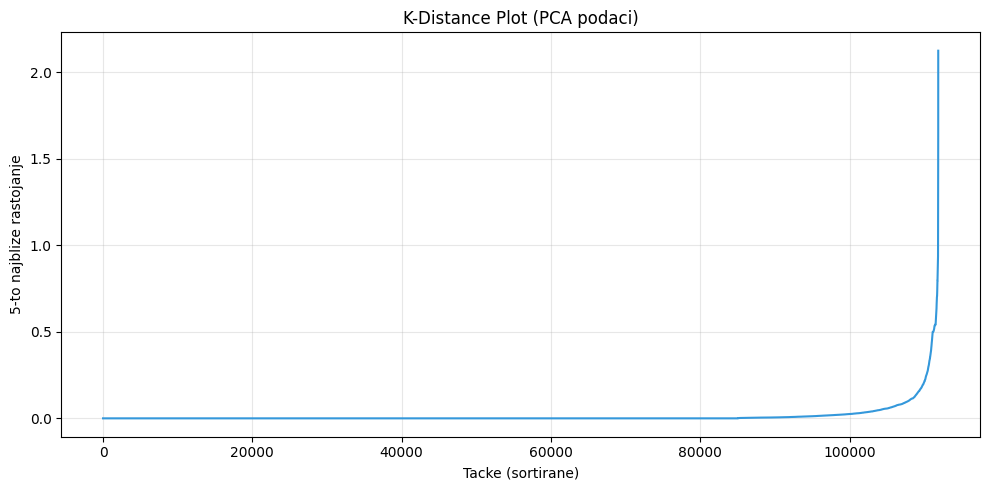

  90. percentil: 0.028
  95. percentil: 0.074
  97. percentil: 0.117
  99. percentil: 0.347


In [45]:
nn_pca = NearestNeighbors(n_neighbors=5)
nn_pca.fit(X_pca)
dist_pca, _ = nn_pca.kneighbors(X_pca)
dist_pca = np.sort(dist_pca[:, 4])

plt.figure(figsize=(10, 5))
plt.plot(dist_pca, color='#3498db', linewidth=1.5)
plt.xlabel('Tacke (sortirane)')
plt.ylabel('5-to najblize rastojanje')
plt.title('K-Distance Plot (PCA podaci)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for p in [90, 95, 97, 99]:
    print(f"  {p}. percentil: {np.percentile(dist_pca, p):.3f}")

In [46]:
# grid search na PCA uzorku
np.random.seed(42)
dbscan_n = 15000
db_idx = np.random.choice(len(X_pca), size=dbscan_n, replace=False)
X_pca_sample = X_pca[db_idx]

eps_vals = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
ms_vals = [5, 10, 15]
db_results = []

for eps in eps_vals:
    for ms in ms_vals:
        dbs = DBSCAN(eps=eps, min_samples=ms)
        lab = dbs.fit_predict(X_pca_sample)
        nc = len(set(lab)) - (1 if -1 in lab else 0)
        noise = (lab == -1).sum() / len(lab) * 100
        s = silhouette_score(X_pca_sample, lab) if nc >= 2 else -1
        db_results.append({'eps': eps, 'min_samples': ms, 'klasteri': nc,
                           'noise%': round(noise, 1), 'silhouette': round(s, 4)})
        print(f"  eps={eps}, ms={ms} -> {nc} klastera, {noise:.1f}% noise")

db_res_df = pd.DataFrame(db_results)
valid = db_res_df[(db_res_df['klasteri'] >= 2) & (db_res_df['noise%'] < 30)]

if len(valid) > 0:
    best_dbpca = valid.loc[valid['silhouette'].idxmax()]
    print(f"\nNajbolji: eps={best_dbpca['eps']}, ms={int(best_dbpca['min_samples'])}, "
          f"klasteri={int(best_dbpca['klasteri'])}, silhouette={best_dbpca['silhouette']}")
else:
    best_dbpca = db_res_df.loc[db_res_df['silhouette'].idxmax()]
    print(f"\nFallback: eps={best_dbpca['eps']}, ms={int(best_dbpca['min_samples'])}")

  eps=1.0, ms=5 -> 8 klastera, 0.0% noise
  eps=1.0, ms=10 -> 4 klastera, 0.3% noise
  eps=1.0, ms=15 -> 3 klastera, 0.6% noise
  eps=1.5, ms=5 -> 1 klastera, 0.0% noise
  eps=1.5, ms=10 -> 1 klastera, 0.0% noise
  eps=1.5, ms=15 -> 1 klastera, 0.0% noise
  eps=2.0, ms=5 -> 1 klastera, 0.0% noise
  eps=2.0, ms=10 -> 1 klastera, 0.0% noise
  eps=2.0, ms=15 -> 1 klastera, 0.0% noise
  eps=2.5, ms=5 -> 1 klastera, 0.0% noise
  eps=2.5, ms=10 -> 1 klastera, 0.0% noise
  eps=2.5, ms=15 -> 1 klastera, 0.0% noise
  eps=3.0, ms=5 -> 1 klastera, 0.0% noise
  eps=3.0, ms=10 -> 1 klastera, 0.0% noise
  eps=3.0, ms=15 -> 1 klastera, 0.0% noise
  eps=3.5, ms=5 -> 1 klastera, 0.0% noise
  eps=3.5, ms=10 -> 1 klastera, 0.0% noise
  eps=3.5, ms=15 -> 1 klastera, 0.0% noise

Najbolji: eps=1.0, ms=15, klasteri=3, silhouette=0.1526


In [47]:
# DBSCAN finalni na PCA + KNN dodela za ostale tacke
np.random.seed(42)
db_full_n = 20000
db_full_idx = np.random.choice(len(X_pca), size=db_full_n, replace=False)
X_pca_db = X_pca[db_full_idx]

dbscan_pca = DBSCAN(eps=best_dbpca['eps'], min_samples=int(best_dbpca['min_samples']))
db_labels = dbscan_pca.fit_predict(X_pca_db)

nc_found = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print(f"DBSCAN PCA: {nc_found} klastera, {(db_labels == -1).sum()} noise tacaka")

if nc_found >= 2:
    non_noise = db_labels != -1
    knn_db = KNeighborsClassifier(n_neighbors=5)
    knn_db.fit(X_pca_db[non_noise], db_labels[non_noise])
    df['DBSCAN_PCA'] = knn_db.predict(X_pca)
else:
    df['DBSCAN_PCA'] = 0
    print("DBSCAN nije razdvojio klastere ni na PCA podacima")

print(df['DBSCAN_PCA'].value_counts().sort_index())

DBSCAN PCA: 3 klastera, 72 noise tacaka
DBSCAN_PCA
0    80551
1    31186
2      141
Name: count, dtype: int64


#### Agglomerative na PCA podacima

In [48]:
np.random.seed(42)
agg_n = 20000
agg_pca_idx = np.random.choice(len(X_pca), size=agg_n, replace=False)
X_pca_agg = X_pca[agg_pca_idx]

agg_pca_sils = []
for k in range(2, 8):
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    lab = agg.fit_predict(X_pca_agg)
    s = silhouette_score(X_pca_agg, lab)
    agg_pca_sils.append({'k': k, 'silhouette': round(s, 4)})
    print(f"  k={k}: silhouette={s:.4f}")

agg_pca_df = pd.DataFrame(agg_pca_sils)
best_agg_pca_k = agg_pca_df.loc[agg_pca_df['silhouette'].idxmax(), 'k']

agg_pca_final = AgglomerativeClustering(n_clusters=int(best_agg_pca_k), linkage='ward')
agg_pca_labels = agg_pca_final.fit_predict(X_pca_agg)

knn_agg_pca = KNeighborsClassifier(n_neighbors=5)
knn_agg_pca.fit(X_pca_agg, agg_pca_labels)
df['Agg_PCA'] = knn_agg_pca.predict(X_pca)

print(f"\nAgglomerative PCA (k={int(best_agg_pca_k)}):")
print(df['Agg_PCA'].value_counts().sort_index())

  k=2: silhouette=0.2719
  k=3: silhouette=0.2138
  k=4: silhouette=0.2139
  k=5: silhouette=0.2241
  k=6: silhouette=0.2314
  k=7: silhouette=0.2308

Agglomerative PCA (k=2):
Agg_PCA
0    80551
1    31327
Name: count, dtype: int64


#### GMM na PCA podacima

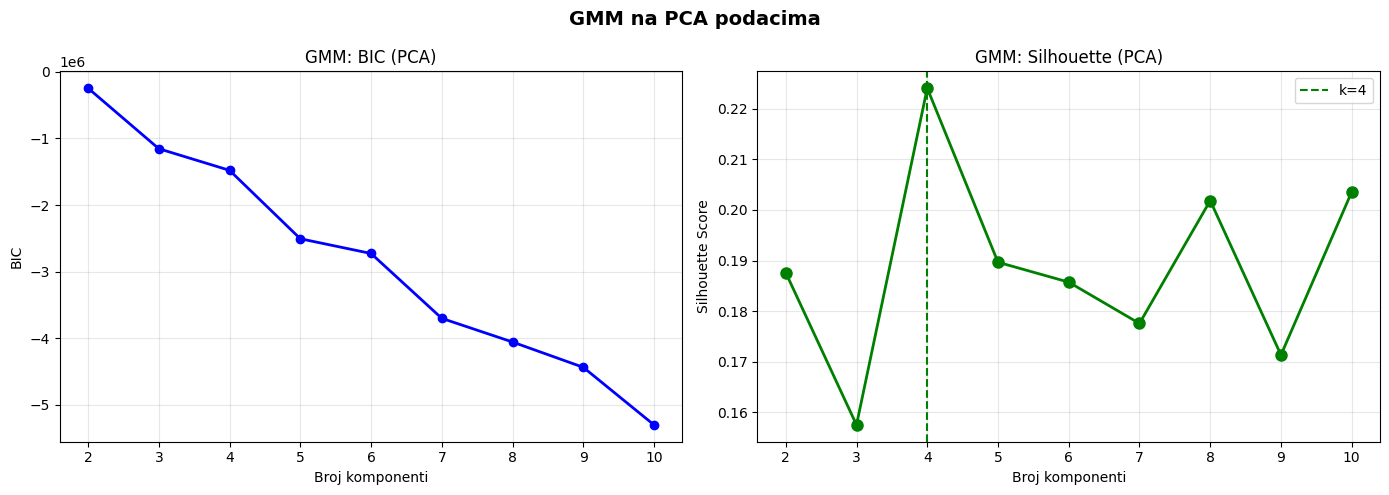

Silhouette -> k=4
BIC -> k=10


In [49]:
bics_pca, gmm_pca_sils = [], []

for k in range(2, 11):
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5)
    gmm.fit(X_pca)
    lab = gmm.predict(X_pca)
    bics_pca.append(gmm.bic(X_pca))
    gmm_pca_sils.append(silhouette_score(X_pca, lab))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(2, 11), bics_pca, 'bo-', linewidth=2)
axes[0].set_xlabel('Broj komponenti')
axes[0].set_ylabel('BIC')
axes[0].set_title('GMM: BIC (PCA)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(2, 11), gmm_pca_sils, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Broj komponenti')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('GMM: Silhouette (PCA)')
axes[1].grid(True, alpha=0.3)

best_gmm_pca_k = range(2, 11)[np.argmax(gmm_pca_sils)]
axes[1].axvline(x=best_gmm_pca_k, color='green', linestyle='--', label=f'k={best_gmm_pca_k}')
axes[1].legend()
plt.suptitle('GMM na PCA podacima', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Silhouette -> k={best_gmm_pca_k}")
print(f"BIC -> k={range(2,11)[np.argmin(bics_pca)]}")

In [50]:
gmm_pca = GaussianMixture(n_components=best_gmm_pca_k, random_state=42, n_init=5)
gmm_pca.fit(X_pca)
df['GMM_PCA'] = gmm_pca.predict(X_pca)

print(f"GMM PCA (k={best_gmm_pca_k}):")
print(df['GMM_PCA'].value_counts().sort_index())
print(f"Pouzdanost: {gmm_pca.predict_proba(X_pca).max(axis=1).mean():.4f}")

GMM PCA (k=4):
GMM_PCA
0    31716
1    16902
2    31327
3    31933
Name: count, dtype: int64
Pouzdanost: 1.0000


#### Poredjenje: Original (38D) vs PCA

In [51]:
pca_algorithms = {
    'K-Means (PCA)': df['KMeans_PCA'],
    'DBSCAN (PCA)': df['DBSCAN_PCA'],
    'Agglomerative (PCA)': df['Agg_PCA'],
    'GMM (PCA)': df['GMM_PCA']
}

comp_pca = []
for name, labels in pca_algorithms.items():
    if len(labels.unique()) < 2:
        comp_pca.append({'Algoritam': name, 'Br. klastera': len(labels.unique()),
            'Silhouette': 'N/A', 'Calinski-Harabasz': 'N/A', 'Davies-Bouldin': 'N/A'})
        continue
    sil = silhouette_score(X_pca, labels)
    ch = calinski_harabasz_score(X_pca, labels)
    db = davies_bouldin_score(X_pca, labels)
    comp_pca.append({'Algoritam': name, 'Br. klastera': len(labels.unique()),
        'Silhouette': round(sil, 4), 'Calinski-Harabasz': round(ch, 2),
        'Davies-Bouldin': round(db, 4)})

comp_pca_df = pd.DataFrame(comp_pca)

comparison_df['Prostor'] = '38D (Original)'
comp_pca_df['Prostor'] = 'PCA (13D)'
full_comparison = pd.concat([comparison_df, comp_pca_df], ignore_index=True)

print("Poredjenje: Original (38D) vs PCA:")
print(full_comparison.to_string(index=False))

Poredjenje: Original (38D) vs PCA:
          Algoritam  Br. klastera Silhouette Calinski-Harabasz Davies-Bouldin Noise (%)        Prostor
            K-Means             2     0.2675          34721.23         1.5966         - 38D (Original)
             DBSCAN             0        N/A               N/A            N/A      0.0% 38D (Original)
      Agglomerative             2     0.2675          34719.93         1.5966         - 38D (Original)
                GMM             2     0.2675          34721.18         1.5966         - 38D (Original)
      K-Means (PCA)             2     0.2717          36429.65         1.5497       NaN      PCA (13D)
       DBSCAN (PCA)             3     0.2057          18316.85         1.4748       NaN      PCA (13D)
Agglomerative (PCA)             2     0.2717          36429.59         1.5497       NaN      PCA (13D)
          GMM (PCA)             4     0.2241          28594.56         1.8152       NaN      PCA (13D)


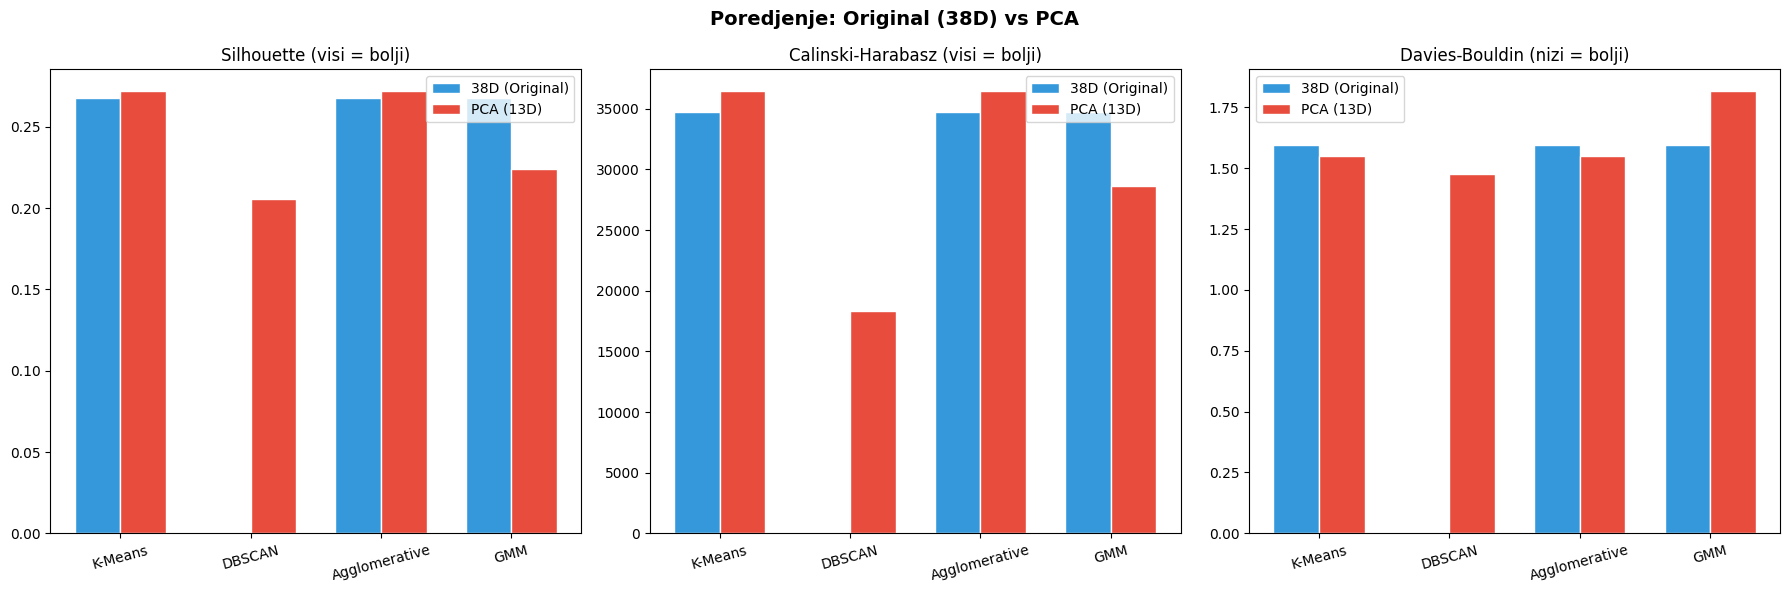

In [52]:
pairs = [
    ('K-Means', 'K-Means (PCA)'),
    ('DBSCAN', 'DBSCAN (PCA)'),
    ('Agglomerative', 'Agglomerative (PCA)'),
    ('GMM', 'GMM (PCA)')
]

metrics = ['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin']
titles = ['Silhouette (visi = bolji)', 'Calinski-Harabasz (visi = bolji)', 'Davies-Bouldin (nizi = bolji)']

fc = full_comparison[full_comparison['Silhouette'] != 'N/A'].copy()
for col in metrics:
    fc[col] = fc[col].astype(float)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
x = np.arange(4)
width = 0.35
algo_names = ['K-Means', 'DBSCAN', 'Agglomerative', 'GMM']

for ax, metric, title in zip(axes, metrics, titles):
    vals_orig = []
    vals_pca = []
    for orig, pca in pairs:
        row_o = fc[fc['Algoritam'] == orig]
        row_p = fc[fc['Algoritam'] == pca]
        vals_orig.append(row_o[metric].values[0] if len(row_o) else 0)
        vals_pca.append(row_p[metric].values[0] if len(row_p) else 0)

    ax.bar(x - width/2, vals_orig, width, label='38D (Original)', color='#3498db', edgecolor='white')
    ax.bar(x + width/2, vals_pca, width, label='PCA (13D)', color='#e74c3c', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(algo_names, rotation=15)
    ax.set_title(title)
    ax.legend()

plt.suptitle('Poredjenje: Original (38D) vs PCA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

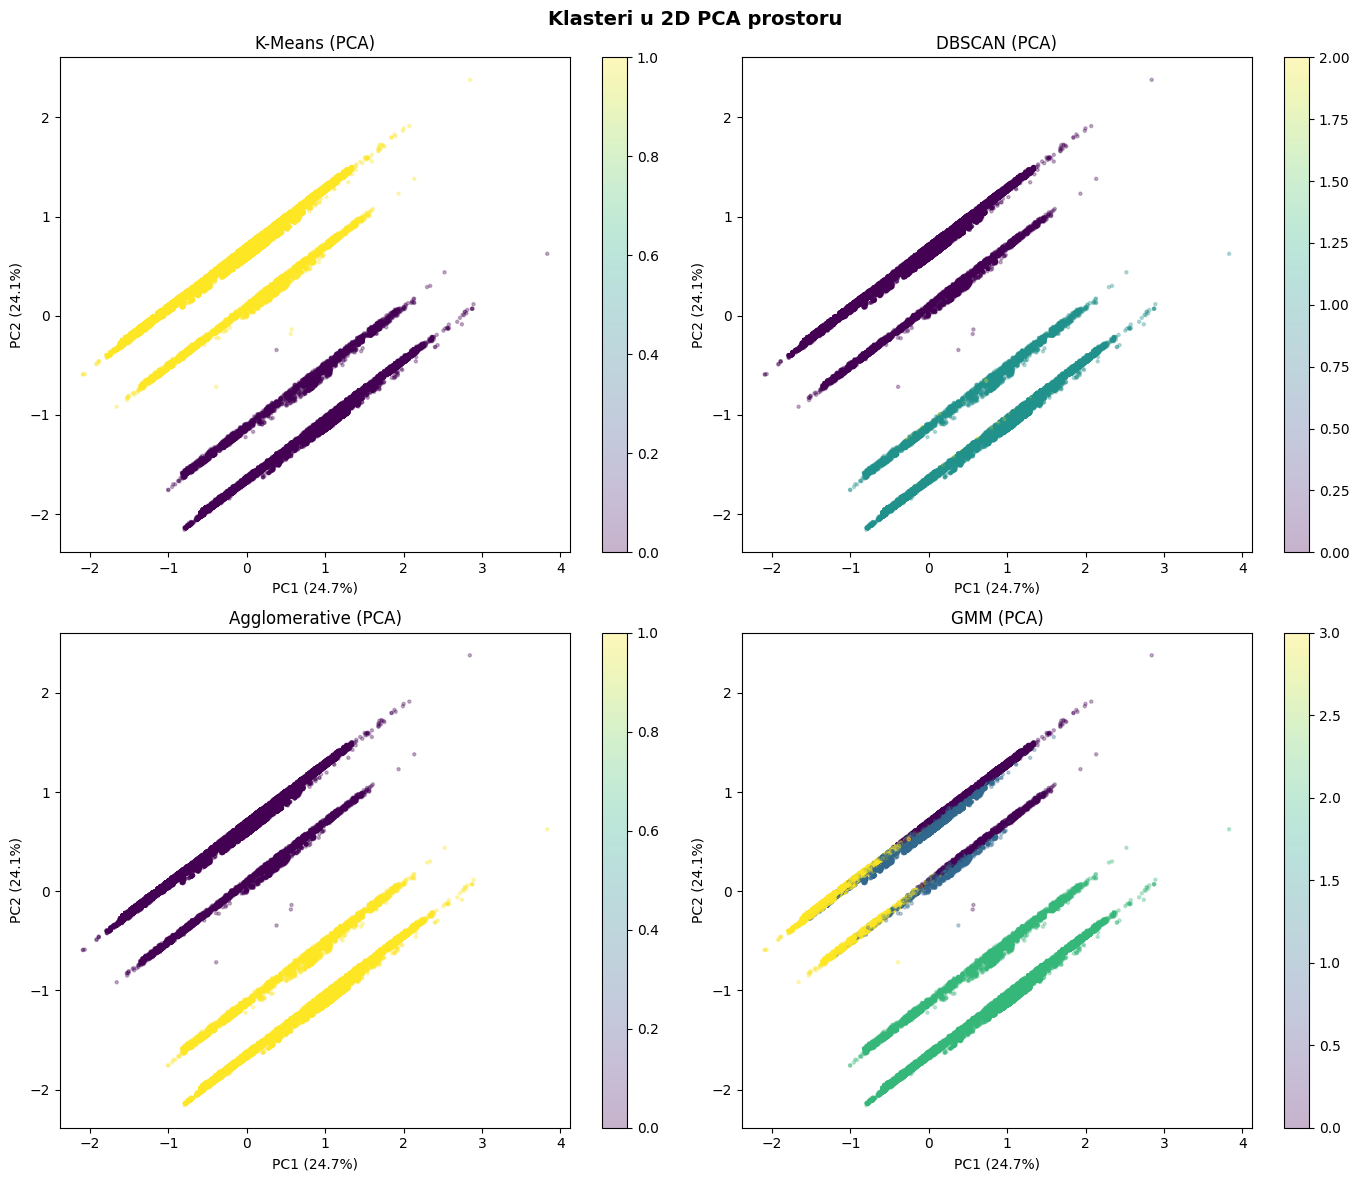

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

pca_cols = ['KMeans_PCA', 'DBSCAN_PCA', 'Agg_PCA', 'GMM_PCA']
titles = ['K-Means', 'DBSCAN', 'Agglomerative', 'GMM']

for ax, col, title in zip(axes.flat, pca_cols, titles):
    scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                         c=df[col], cmap='viridis', alpha=0.3, s=5)
    ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
    ax.set_title(f'{title} (PCA)')
    plt.colorbar(scatter, ax=ax)

plt.suptitle('Klasteri u 2D PCA prostoru', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### t-SNE vizuelizacija

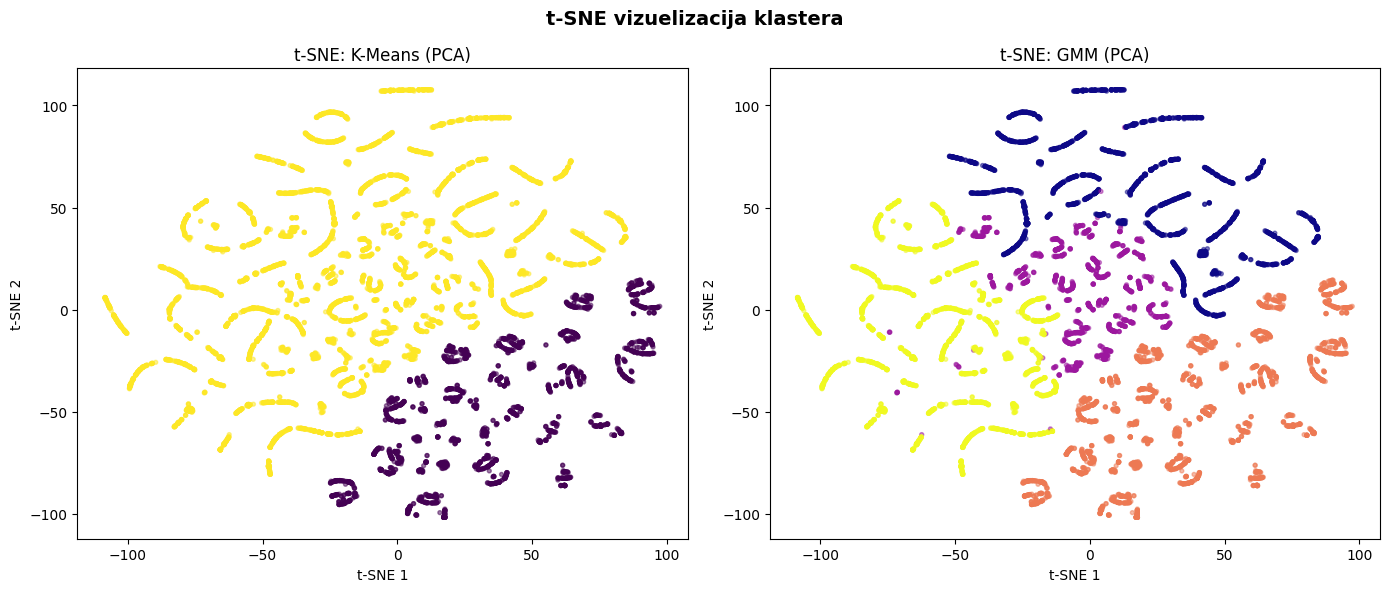

In [54]:
np.random.seed(42)
tsne_n = min(10000, len(X_pca))
tsne_idx = np.random.choice(len(X_pca), size=tsne_n, replace=False)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca[tsne_idx])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1],
    c=df['KMeans_PCA'].iloc[tsne_idx].values, cmap='viridis', alpha=0.5, s=8)
axes[0].set_title('t-SNE: K-Means (PCA)')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
    c=df['GMM_PCA'].iloc[tsne_idx].values, cmap='plasma', alpha=0.5, s=8)
axes[1].set_title('t-SNE: GMM (PCA)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

plt.suptitle('t-SNE vizuelizacija klastera', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Analiza i obrada outlier-a

Detektujemo outliere na PCA podacima i testiramo uticaj na kvalitet klasterizacije.

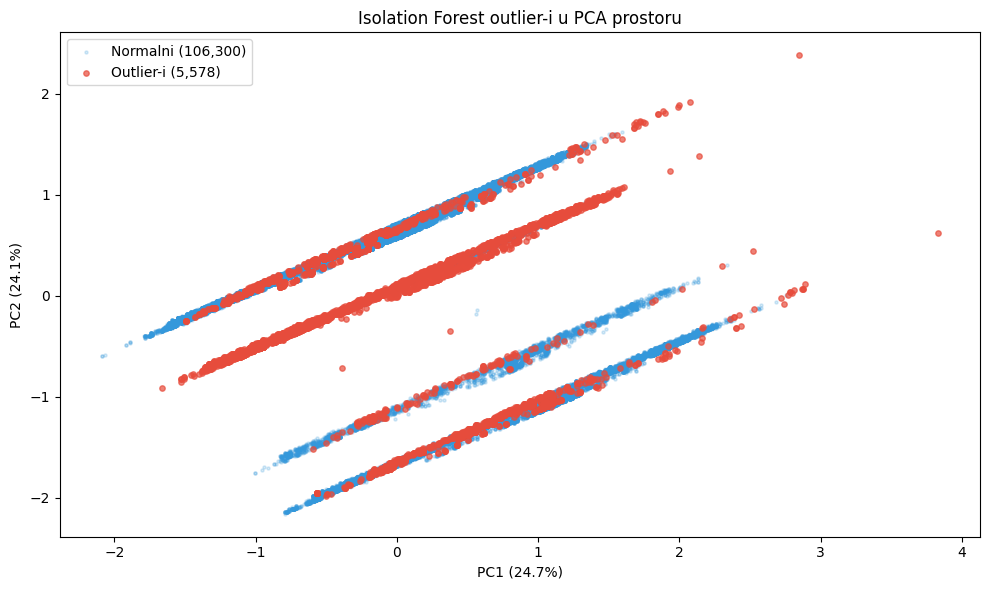

Outlier-i: 5578 od 111878 (5.0%)


In [55]:
iso_forest = IsolationForest(contamination=0.05, random_state=42, n_estimators=100)
iso_labels = iso_forest.fit_predict(X_pca)
iso_mask = iso_labels == -1

plt.figure(figsize=(10, 6))
plt.scatter(X_pca_2d[~iso_mask, 0], X_pca_2d[~iso_mask, 1],
            c='#3498db', alpha=0.2, s=5, label=f'Normalni ({(~iso_mask).sum():,})')
plt.scatter(X_pca_2d[iso_mask, 0], X_pca_2d[iso_mask, 1],
            c='#e74c3c', alpha=0.7, s=15, label=f'Outlier-i ({iso_mask.sum():,})')
plt.xlabel(f'PC1 ({explained[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained[1]*100:.1f}%)')
plt.title('Isolation Forest outlier-i u PCA prostoru')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Outlier-i: {iso_mask.sum()} od {len(X_pca)} ({iso_mask.sum()/len(X_pca)*100:.1f}%)")

### Uticaj outlier-a na klasterizaciju

In [56]:
# K-Means sa vs bez outlier-a
X_pca_clean = X_pca[~iso_mask]
km_clean = KMeans(n_clusters=optimal_k_pca, random_state=42, n_init=10)
labels_clean = km_clean.fit_predict(X_pca_clean)

labels_full = df['KMeans_PCA'].values
sil_full = silhouette_score(X_pca, labels_full)
ch_full = calinski_harabasz_score(X_pca, labels_full)
db_full = davies_bouldin_score(X_pca, labels_full)

sil_clean = silhouette_score(X_pca_clean, labels_clean)
ch_clean = calinski_harabasz_score(X_pca_clean, labels_clean)
db_clean = davies_bouldin_score(X_pca_clean, labels_clean)

outlier_comp = pd.DataFrame({
    'Metrika': ['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin'],
    'Sa outlier-ima': [round(sil_full, 4), round(ch_full, 2), round(db_full, 4)],
    'Bez outlier-a': [round(sil_clean, 4), round(ch_clean, 2), round(db_clean, 4)],
    'Bolji': [
        'Bez' if sil_clean > sil_full else 'Sa',
        'Bez' if ch_clean > ch_full else 'Sa',
        'Bez' if db_clean < db_full else 'Sa'
    ]
})

print(f"K-Means (k={optimal_k_pca}) - uticaj outlier-a na PCA podacima:")
print(outlier_comp.to_string(index=False))

K-Means (k=2) - uticaj outlier-a na PCA podacima:
          Metrika  Sa outlier-ima  Bez outlier-a Bolji
       Silhouette          0.2717         0.2819   Bez
Calinski-Harabasz      36429.6500     36855.4700   Bez
   Davies-Bouldin          1.5497         1.5161   Bez


## Profilisanje klastera

Analiziramo karakteristike svakog klastera pomocu originalnih feature-ova.

In [57]:
best_col = 'KMeans_PCA'

for cluster in sorted(df[best_col].unique()):
    cdata = df[df[best_col] == cluster]
    print(f"\nKlaster {cluster} ({len(cdata):,} narudzbina, {len(cdata)/len(df)*100:.1f}%)")
    print(f"  Iznos: prosek={cdata['Amount'].mean():.0f} INR, median={cdata['Amount'].median():.0f} INR")
    print(f"  Kolicina: {cdata['Qty'].mean():.2f}")
    print(f"  B2B: {cdata['B2B'].mean()*100:.1f}%")
    top_cats = cdata['Category'].value_counts().head(3)
    for cat, cnt in top_cats.items():
        print(f"    {cat}: {cnt:,} ({cnt/len(cdata)*100:.1f}%)")


Klaster 0 (31,328 narudzbina, 28.0%)
  Iznos: prosek=667 INR, median=635 INR
  Kolicina: 1.01
  B2B: 0.9%
    Set: 11,723 (37.4%)
    kurta: 11,305 (36.1%)
    Western Dress: 5,592 (17.8%)

Klaster 1 (80,550 narudzbina, 72.0%)
  Iznos: prosek=662 INR, median=603 INR
  Kolicina: 1.00
  B2B: 0.7%
    kurta: 31,933 (39.6%)
    Set: 31,716 (39.4%)
    Western Dress: 7,685 (9.5%)


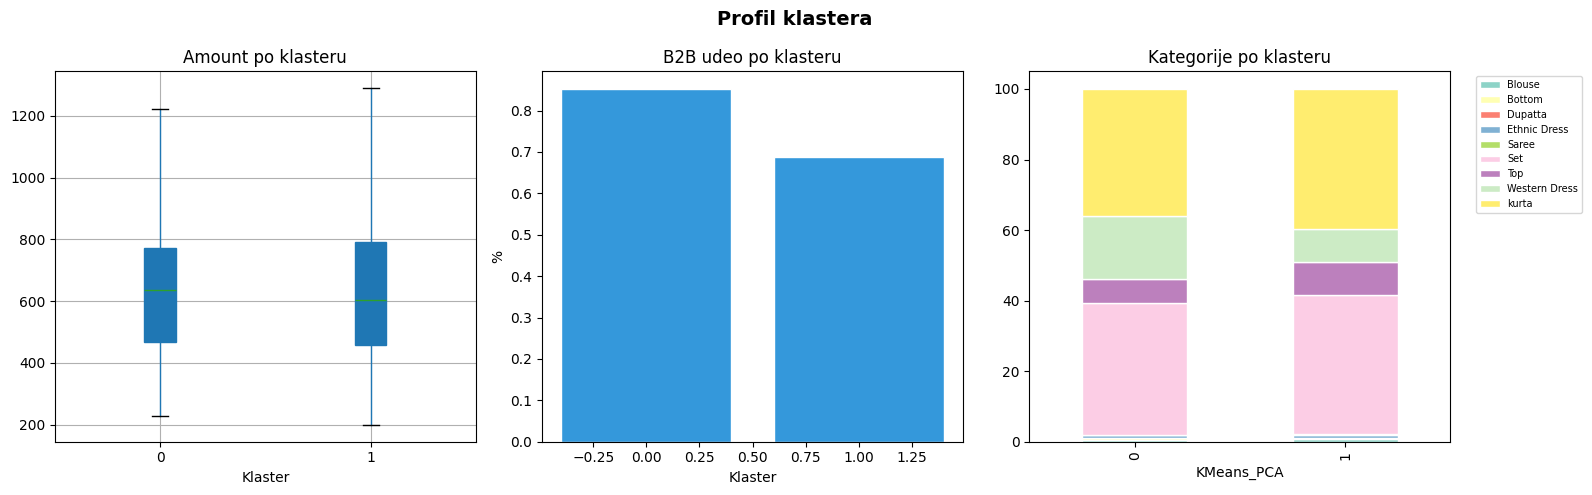

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df.boxplot(column='Amount', by=best_col, ax=axes[0], patch_artist=True, showfliers=False)
axes[0].set_title('Amount po klasteru')
axes[0].set_xlabel('Klaster')

b2b_pct = df.groupby(best_col)['B2B'].mean() * 100
axes[1].bar(b2b_pct.index, b2b_pct.values, color='#3498db', edgecolor='white')
axes[1].set_title('B2B udeo po klasteru')
axes[1].set_xlabel('Klaster')
axes[1].set_ylabel('%')

cat_cluster = pd.crosstab(df[best_col], df['Category'], normalize='index') * 100
cat_cluster.plot(kind='bar', stacked=True, ax=axes[2], colormap='Set3', edgecolor='white')
axes[2].set_title('Kategorije po klasteru')
axes[2].legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)

plt.suptitle('Profil klastera', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

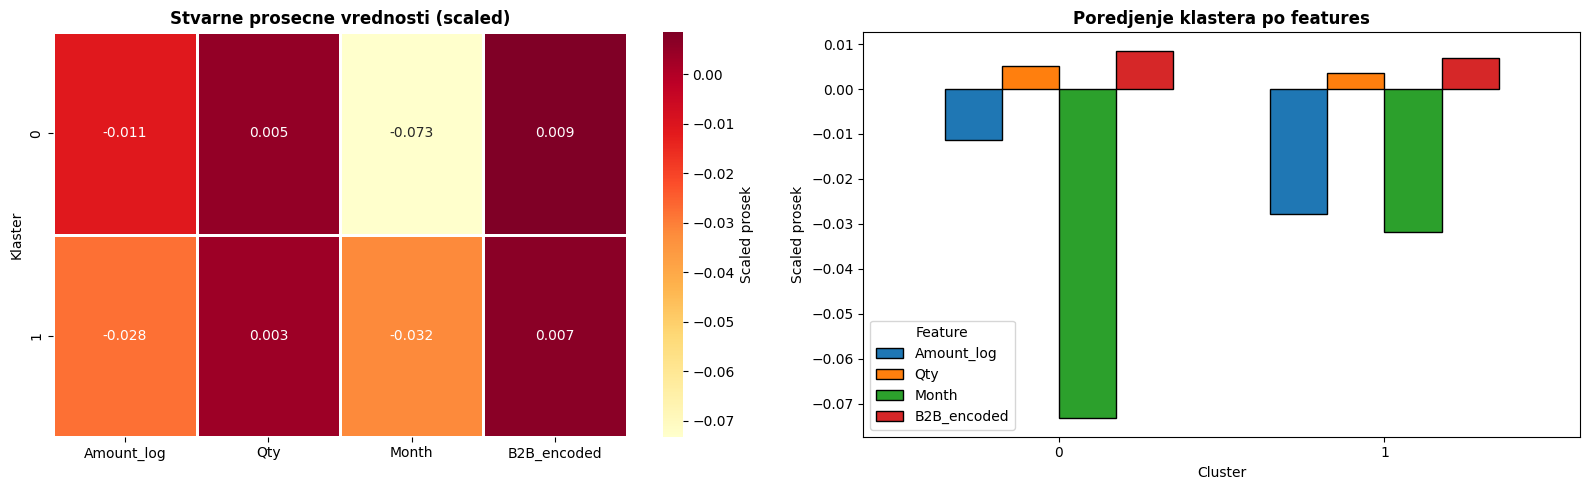

In [59]:
key_feats = ['Amount_log', 'Qty', 'Month', 'B2B_encoded']
cl_data = df_scaled.copy()
cl_data['Cluster'] = df[best_col].values
cl_means = cl_data.groupby('Cluster')[key_feats].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sb.heatmap(cl_means, annot=True, fmt='.3f', cmap='YlOrRd',
           linewidths=1, cbar_kws={'label': 'Scaled prosek'}, ax=axes[0])
axes[0].set_title('Stvarne prosecne vrednosti (scaled)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Klaster')

cl_means.plot(kind='bar', ax=axes[1], edgecolor='black', width=0.7)
axes[1].set_title('Poredjenje klastera po features', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Scaled prosek')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Feature')

plt.tight_layout()
plt.show()


## Zakljucak

**Priprema podataka:**  
Dataset od 111,878 narudzbina je ociscen i transformisan. Log transformacija za Amount je ispravila desnu zakrivljenost distribucije. OneHotEncoding za 5 kategorijskih varijabli je rezultirao u 38 feature-ova, a redundantne kolone su uklonjene na osnovu korelacione analize.

**Klasterizacija na originalnim podacima (38D):**  
Svi algoritmi su dali gotovo identicne rezultate. Podelu na 2 klastera sa Silhouette oko 0.267. DBSCAN nije uspeo da razdvoji nista. Ovo je posledica u prostoru sa 38 dimenzija (vecinom binarnih od OHE) rastojanja izmedju tacaka postaju uniformna i algoritmi ne mogu da prepoznaju finu strukturu.

**Redukcija dimenzionalnosti:**  
PCA je pokazao da se moze sacuvati 95% varijanse sa znatno manje dimenzija. Na redukovanim podacima DBSCAN je uspeo da pronadje klastere, a ostali algoritmi su dali raznolikije rezultate.

**Outlier analiza:**  
Isolation Forest je detektovao 5% outlier-a. Poredjenje K-Means sa i bez outlier-a pokazuje da uklanjanje outlier-a utice na metrike kvaliteta klastera, sto potvrdjuje da je obrada outlier-a bitan korak u pipeline-u.

**Zakljucak:**  
Redukcija dimenzionalnosti je bila kljucan korak za dobijanje smislenih klastera na OneHot-enkodovanim podacima. Identifikovani segmenti kupaca se mogu iskoristiti za ciljani marketing, personalizaciju ponude i optimizaciju inventara.